# Image classification models
## Dependencies

In [6]:
%%capture
!cmd /c dependencies.bat 

### Imports


In [1]:
import tensorflow as tf
print("Dispositivos GPU:", tf.config.list_physical_devices('GPU'))

Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import torch
import time

In [3]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

In [4]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.regularizers import l2

In [5]:
from functions import *
import cv2

In [6]:
import re

In [7]:
import joblib

In [8]:
random.seed(42)
tf.random.set_seed(42)

## Data


In [10]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [11]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'dataset_multimodal_final.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']
['dataset_multimodal_final.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']


In [12]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path, header =0, names=["filename", "label"])

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [13]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\dataset_multimodal_final.csv
../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007
../capturas/capturas_256x256/capturasVR\Session_008
../capturas/capturas_256x256/capturasVR\Session_009
../capturas/capturas_256x256/capturasVR\Session_010
../capturas/capturas_256x256/capturasVR\Session_011
../capturas/capturas_256x256/capturasVR\Session_012
../capturas/capturas_256x256/capturasVR\Session_013
../capturas/capturas_256x256/capturasVR\Session_014
../capturas/capturas_256x256/capturasVR\Session_015
../capturas/capturas_256x256/capturasVR\Session_016
../capturas/capturas_256x256/capturasVR\Session_017


## Auxiliary functions

In [11]:
def show_correct_and_predicted_labels(test_labels, class_names, y_pred_classes, class_ind):
    y_true_class = [i for i, val in enumerate(test_labels) if val == class_ind]
    correct = []
    print(f"Cantidad de imágenes reales de {class_names[class_ind]}: {len(y_true_class)}")
    for idx in y_true_class:
        if y_pred_classes[idx] == class_ind:
            correct.append(idx)
        print(f"Índice: {idx} - Clase real: {class_names[test_labels[idx]]} - Clase predicha: {class_names[y_pred_classes[idx]]}")
    print(f"{len(correct)} clasificaciones correctas para {class_names[class_ind]}: {correct}")
    return correct

In [12]:
def show_image_and_label(images, labels, image_names, num_images=20):
  
    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"{name}\n{labels[i]}"
        
        plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

In [13]:
def show_predictions_tf_dataset(model, dataset, encoder, target_class_name=None, num_images=20):
    """
    Extrae imágenes de un tf.data.Dataset, predice y muestra resultados.
    Si target_class_name existe, filtra solo para esa clase.
    """
    all_images = []
    all_labels = []
    all_preds = []

    # 1. Obtener ID de la clase objetivo
    target_idx = encoder.transform([target_class_name])[0] if target_class_name else None

    # 2. Iterar sobre el dataset para recolectar imágenes y predecir
    # (Solo tomamos lo necesario para no agotar la memoria)
    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        
        # Convertir labels de test (que suelen ser indices) a numpy
        labels = labels.numpy()
        
        for i in range(len(labels)):
            # Si hay filtro, verificar si la clase real coincide
            if target_idx is None or labels[i] == target_idx:
                all_images.append(imgs[i].numpy())
                all_labels.append(labels[i])
                all_preds.append(pred_classes[i])
            
            if len(all_images) >= num_images:
                break
        if len(all_images) >= num_images:
            break

    if not all_images:
        print(f"No se encontraron imágenes para la clase: {target_class_name}")
        return

    # 3. Visualización
    num_to_show = len(all_images)
    cols = 5
    rows = (num_to_show // cols) + (1 if num_to_show % cols != 0 else 0)
    
    fig = plt.figure(figsize=(15, 3 * rows))
    
    for i in range(num_to_show):
        plt.subplot(rows, cols, i + 1)
        
        # Re-escalar para mostrar (si es ResNet está en [0,1], si es MobileNet en [-1,1])
        img_display = all_images[i]
        if img_display.min() < 0: # Caso MobileNet [-1, 1]
            img_display = (img_display + 1) / 2
            
        plt.imshow(img_display)
        plt.axis("off")
        
        real_name = encoder.inverse_transform([all_labels[i]])[0]
        pred_name = encoder.inverse_transform([all_preds[i]])[0]
        
        color = "blue" if all_labels[i] == all_preds[i] else "red"
        plt.title(f"Real: {real_name}\nPred: {pred_name}", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

In [14]:
def show_image_by_index(paths, indexes):

    if indexes == []:
        print("No hay índices")
        return
    for index in indexes:
  
        if index < 0 or index >= len(paths):
            print(f"Índice {index} fuera de rango. El conjunto tiene {len(paths)} imágenes.")
            return
        
        path = paths[index]
        img = plt.imread(path)
        

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Imagen en índice {index}")
        plt.show()

## Get dataset

In [14]:
(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder = get_paths_and_labels(df, test_size=0.2)

# Pesos para penalizar los errores al clasificar mal la clase minoritaria
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

dict_weights = dict(enumerate(weights))


print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(train_paths) + len(val_paths) + len(test_paths)}")
print(f"Entrenamiento: {len(train_paths)}")
print(f"Validación:    {len(val_paths)}")
print(f"Test:          {len(test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

['colocarNiquel' 'colocarPila' 'colocarSoporteSup' 'soldar']
ID 0 -> Clase: colocarNiquel
ID 1 -> Clase: colocarPila
ID 2 -> Clase: colocarSoporteSup
ID 3 -> Clase: soldar
Total: 7699
Entrenamiento: 4927
Validación:    1232
Test:          1540

Distribución de clases en el dataset completo:
label
colocarPila          3184
soldar               2256
colocarNiquel        2022
colocarSoporteSup     237
Name: count, dtype: int64
label
colocarPila          41.356020
soldar               29.302507
colocarNiquel        26.263151
colocarSoporteSup     3.078322
Name: proportion, dtype: float64


c:\Users\marci\Desktop\tfm\TFM_InteligentTutor\modelos\functions\plottingFunctions.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


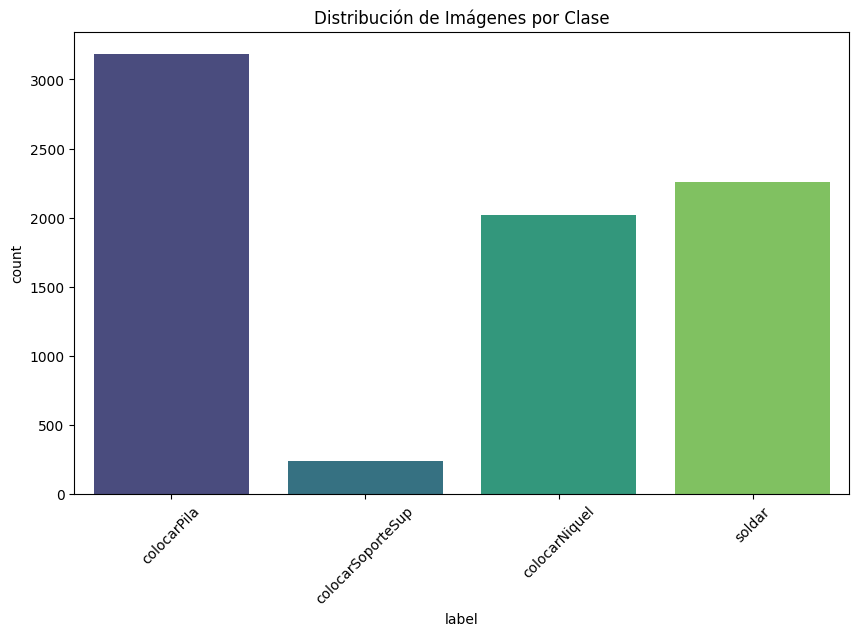

In [15]:
show_class_distribution(df)

In [16]:
def training_pipeline(model, train_ds, val_ds, test_ds, patience=3, epochs=10, lr=0.005, compilation = 'cnn', dict_weights=None):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=patience*2, 
        verbose=1, 
        restore_best_weights=True
    )

    if compilation == 'svm':
        model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SquaredHinge(), 
        metrics=['accuracy']  
        )              

    else:
        model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
        )
        
    history = model.fit(
        train_ds, 
        epochs=epochs, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

    print("\nEvaluando en Entrenamiento...")
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)
    print("Evaluando en Test...")
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    return test_acc, train_acc, train_loss, test_loss, history

## CNNs

In [17]:
class_names = encoder.classes_ 

### ResNet50

In [57]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, 16, '0_1', True)

In [81]:
from tensorflow.keras.applications.resnet import preprocess_input
batch_size = 16
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .flat_map(augment_if_minority)
            .shuffle(buffer_size=1000)
            .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
          .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
           .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

In [82]:
base_resnet50 = ResNet50(
    weights = 'imagenet',
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3),  # if include_top true input shape must be (224, 224, 3) 
    pooling = "avg"
)

#base_resnet50.trainable = False

model_resnet50 = Sequential([
    base_resnet50,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])


# inputs = tf.keras.Input(shape=(256, 256, 3))
# # We make sure that the base_model is running in inference mode here,
# # by passing `training=False`. This is important for fine-tuning, as you will
# # learn in a few paragraphs.
# x = base_resnet50(inputs, training=False)
# # Convert features of shape `base_model.output_shape[1:]` to vectors
# outputs = layers.Dense(4, activation='softmax')(x)
# model_resnet50 = tf.keras.Model(inputs, outputs)


epochs = 20

test_acc_resnet50, train_acc_resnet50, train_loss_resnet50, test_loss_resnet50, history_resnet50 = training_pipeline(model_resnet50, train_ds, val_ds, test_ds, patience=3, epochs=epochs, lr=0.001, dict_weights=dict_weights)
print(f"Test accuracy: {test_acc_resnet50}\nTrain accuracy: {train_acc_resnet50}")
print(f"Test loss: {test_loss_resnet50}\nTrain loss: {train_loss_resnet50}")

Epoch 1/20
318/318 [==============================] - 56s 156ms/step - loss: 0.7109 - accuracy: 0.8080 - val_loss: 339.2130 - val_accuracy: 0.2622 - lr: 0.0010
Epoch 2/20
318/318 [==============================] - 50s 153ms/step - loss: 0.3373 - accuracy: 0.8968 - val_loss: 5.3032 - val_accuracy: 0.5795 - lr: 0.0010
Epoch 3/20
318/318 [==============================] - 50s 154ms/step - loss: 0.3028 - accuracy: 0.9059 - val_loss: 0.2914 - val_accuracy: 0.9123 - lr: 0.0010
Epoch 4/20
318/318 [==============================] - 50s 155ms/step - loss: 0.1984 - accuracy: 0.9435 - val_loss: 19.4387 - val_accuracy: 0.1542 - lr: 0.0010
Epoch 5/20
318/318 [==============================] - 50s 155ms/step - loss: 0.2326 - accuracy: 0.9378 - val_loss: 1.7395 - val_accuracy: 0.6664 - lr: 0.0010
Epoch 6/20
318/318 [==============================] - ETA: 0s - loss: 0.2112 - accuracy: 0.9392
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
318/318 [==========================

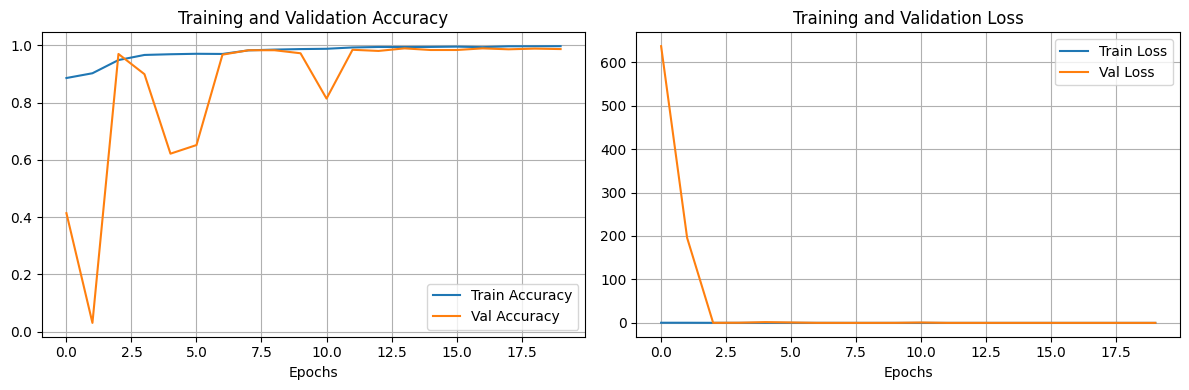

In [77]:
plot_from_history(history_resnet50)

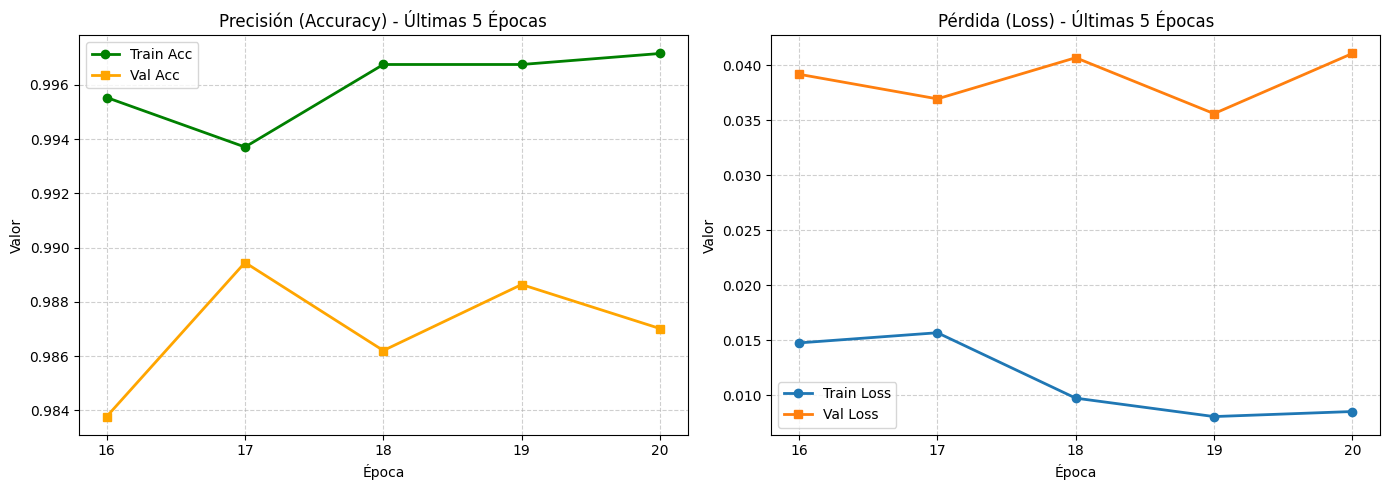

In [78]:
show_last_epochs(history_resnet50, idx = 5)

In [75]:
model_resnet50.save("multiclassModels\modelo_resnet50.h5")
save_history(history_resnet50, "multiclassHistories\history_resnet50.pkl")

In [22]:
model_resnet50 = load_model("multiclassModels\modelo_resnet50.h5")
history_resnet50 = load_history("multiclassHistories\history_resnet50.pkl")

Historial cargado desde multiclassHistories\history_resnet50.pkl.


In [83]:
y_pred_resnet50 = model_resnet50.predict(test_ds)
y_pred_classes_resnet50 = y_pred_resnet50.argmax(axis=1)

f1_resnet50_db = f1_score(test_labels, y_pred_classes_resnet50, average="weighted")
print(f"F1 Score ResNet50: {f1_resnet50_db}")
print("-------------------------------------")

print("Classification Report ResNet50:")
print(classification_report(test_labels, y_pred_classes_resnet50, target_names=class_names))

97/97 [==============================] - 5s 44ms/step
F1 Score ResNet50: 0.9794410620128847
-------------------------------------
Classification Report ResNet50:
                   precision    recall  f1-score   support

    colocarNiquel       0.98      0.94      0.96       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.81      0.98      0.88        47
           soldar       0.97      0.99      0.98       451

         accuracy                           0.98      1540
        macro avg       0.94      0.98      0.96      1540
     weighted avg       0.98      0.98      0.98      1540



In [84]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_resnet50, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1129  | 6     | 23    | 382   |OK
colocarPila          | 901   | 2     | 2     | 635   |OK
colocarSoporteSup    | 1482  | 11    | 1     | 46    |OK
soldar               | 1076  | 13    | 6     | 445   |OK
---------------------------------------------------------------------------


Falsos FP de colocarSoporteSup: 12
=========== Falsos FP de colocarSoporteSup ===========


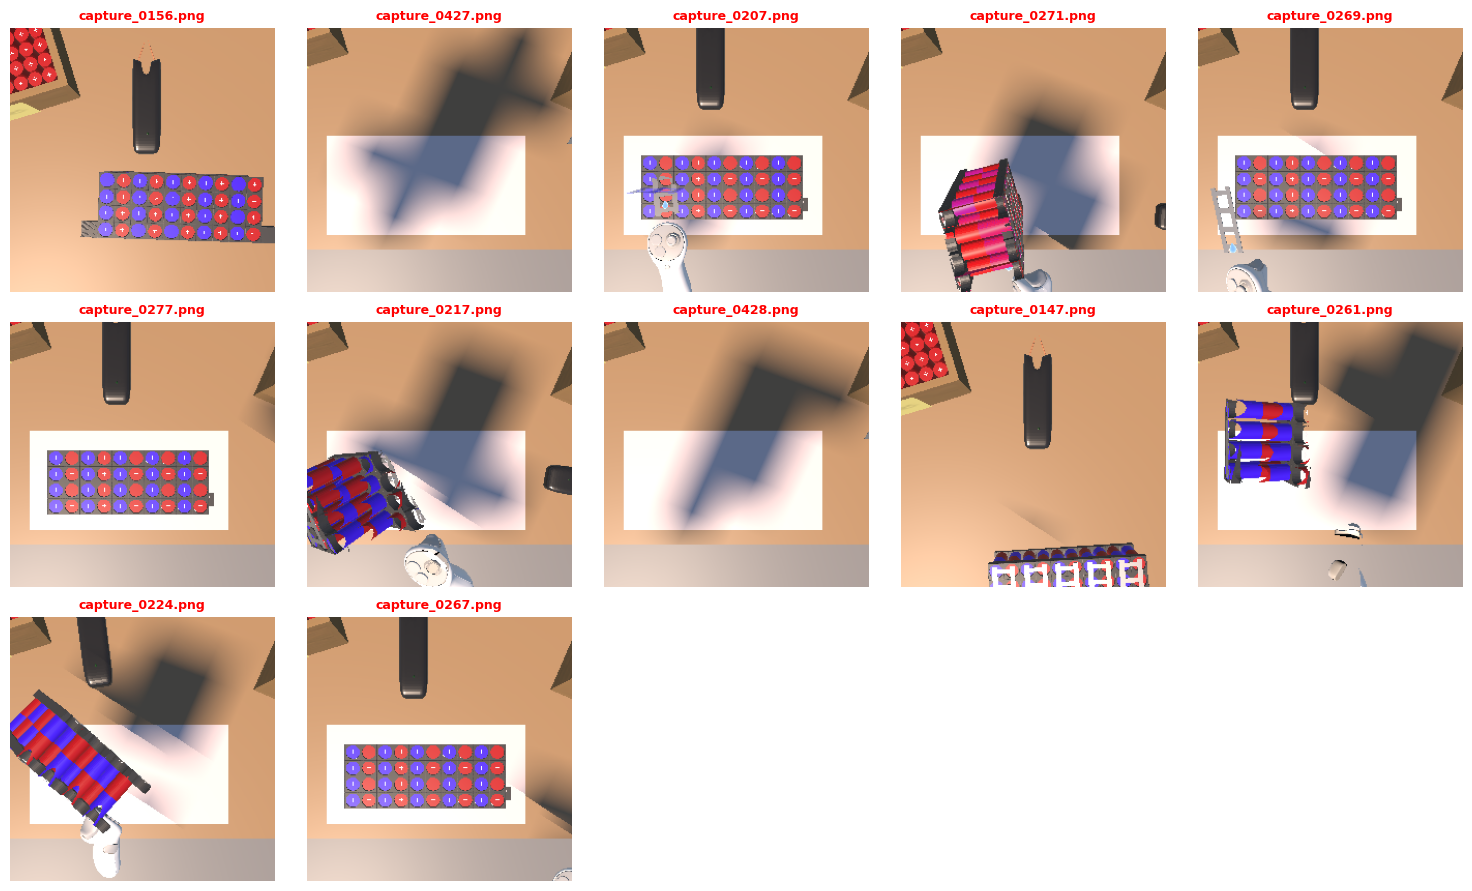

In [64]:
show_false_labels_multiclass(test_labels, test_paths, class_names, y_pred_classes_resnet50, 2, 'FP')

### ResNet50V2

In [56]:
from keras.applications import ResNet50V2

In [57]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, 16, '0_1')

In [58]:
base_resnet50V2 = ResNet50V2(
    weights = None,
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3),  # if include_top true input shape must be (224, 224, 3) 
    pooling = "avg"
)

#base_resnet50V2.trainable = False

model_resnet50V2 = Sequential([
    base_resnet50V2,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])



# inputs = tf.keras.Input(shape=(256, 256, 3))
# # We make sure that the base_model is running in inference mode here,
# # by passing `training=False`. This is important for fine-tuning, as you will
# # learn in a few paragraphs.
# x = base_resnet50V2(inputs, training=False)
# # Convert features of shape `base_model.output_shape[1:]` to vectors
# outputs = layers.Dense(4, activation='softmax')(x)
# model_resnet50V2 = tf.keras.Model(inputs, outputs)


epochs = 20

test_acc_resnet50V2, train_acc_resnet50V2, train_loss_resnet50V2, test_loss_resnet50V2, history_resnet50V2 = training_pipeline(model_resnet50V2, train_ds, val_ds, test_ds, patience=3, epochs=epochs, lr=0.001, dict_weights=dict_weights)
print(f"Test accuracy: {test_acc_resnet50V2}\nTrain accuracy: {train_acc_resnet50V2}")
print(f"Test loss: {test_loss_resnet50V2}\nTrain loss: {train_loss_resnet50V2}")

Epoch 1/20
308/308 [==============================] - 50s 140ms/step - loss: 0.3358 - accuracy: 0.8624 - val_loss: 4.5026 - val_accuracy: 0.3149 - lr: 0.0010
Epoch 2/20
308/308 [==============================] - 42s 137ms/step - loss: 0.2351 - accuracy: 0.9038 - val_loss: 6.7889 - val_accuracy: 0.3588 - lr: 0.0010
Epoch 3/20
308/308 [==============================] - 43s 139ms/step - loss: 0.1203 - accuracy: 0.9556 - val_loss: 1.4692 - val_accuracy: 0.6112 - lr: 0.0010
Epoch 4/20
308/308 [==============================] - 43s 139ms/step - loss: 0.0923 - accuracy: 0.9677 - val_loss: 31.6694 - val_accuracy: 0.2930 - lr: 0.0010
Epoch 5/20
308/308 [==============================] - 43s 141ms/step - loss: 0.0942 - accuracy: 0.9669 - val_loss: 0.5250 - val_accuracy: 0.9513 - lr: 0.0010
Epoch 6/20
308/308 [==============================] - 43s 140ms/step - loss: 0.0626 - accuracy: 0.9769 - val_loss: 0.6875 - val_accuracy: 0.8255 - lr: 0.0010
Epoch 7/20
308/308 [==============================]

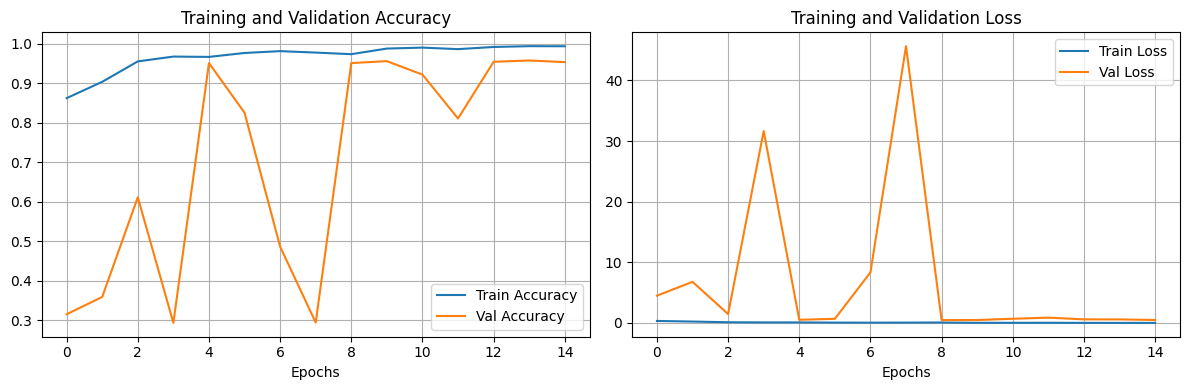

In [59]:
plot_from_history(history_resnet50V2)

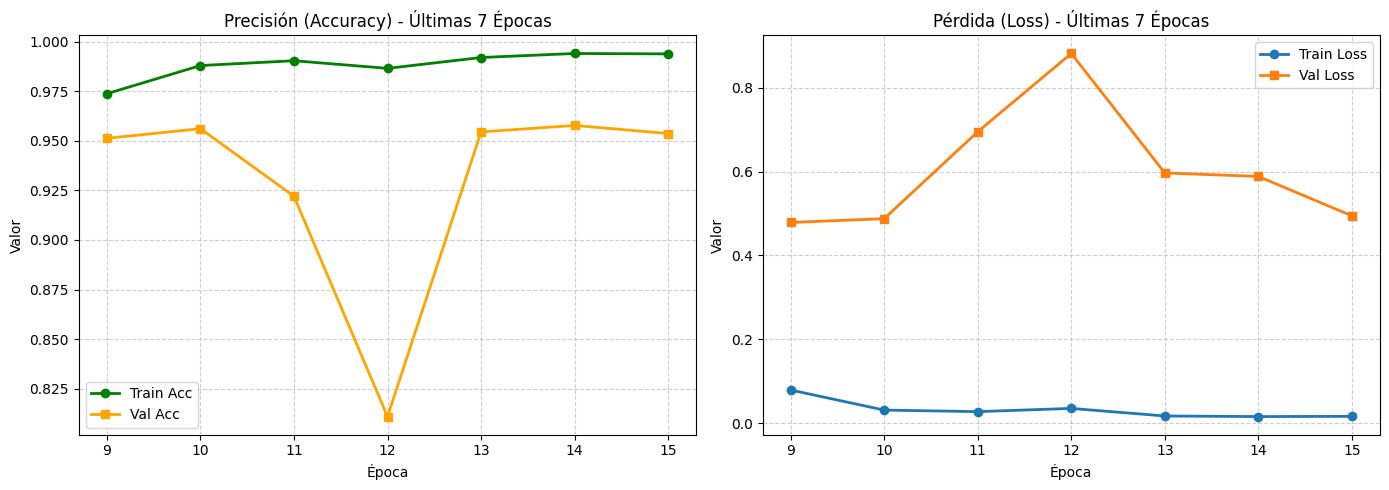

In [60]:
show_last_epochs(history_resnet50V2, 7)

In [61]:
y_pred_resnet50V2 = model_resnet50V2.predict(test_ds)
y_pred_classes_resnet50V2 = y_pred_resnet50V2.argmax(axis=1)

f1_resnet50V2_db = f1_score(test_labels, y_pred_classes_resnet50V2, average="weighted")
print(f"F1 Score ResNet50V2: {f1_resnet50V2_db}")
print("-------------------------------------")

print("Classification Report ResNet50V2 db + no weights:")
print(classification_report(test_labels, y_pred_classes_resnet50V2, target_names=class_names))

97/97 [==============================] - 4s 37ms/step
F1 Score ResNet50V2: 0.9371922817387052
-------------------------------------
Classification Report ResNet50V2 db + no weights:
                   precision    recall  f1-score   support

    colocarNiquel       0.86      0.98      0.91       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.00      0.00      0.00        47
           soldar       0.98      0.96      0.97       451

         accuracy                           0.95      1540
        macro avg       0.71      0.73      0.72      1540
     weighted avg       0.93      0.95      0.94      1540



In [62]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_resnet50V2, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1069  | 66    | 8     | 397   |OK
colocarPila          | 901   | 2     | 1     | 636   |OK
colocarSoporteSup    | 1492  | 1     | 47    | 0     | >25%
soldar               | 1082  | 7     | 20    | 431   |OK
---------------------------------------------------------------------------


### EfficientNetB0 - Tensorflow

In [ ]:
from tensorflow.keras.applications import EfficientNetB0 # needs values between 0-255

In [122]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, 16, None, True)

In [91]:
from tensorflow.keras.applications import efficientnet
batch_size = 32
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            #.flat_map(augment_if_minority)
           # .shuffle(buffer_size=1000)
            .map(lambda x, y: (efficientnet.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
          .map(lambda x, y: (efficientnet.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
           .map(lambda x, y: (efficientnet.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

In [123]:
start_time = time.time()

base_efficientNetB0 = EfficientNetB0(
    include_top = None,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"  # probar con max
)

model_efficientNetB0 = Sequential([
    base_efficientNetB0,
    layers.Dropout(0.5),  # Dropout para reducir overfitting
    layers.Dense(4, activation='softmax')   # 4 clases
])

# base_efficientNetB0.trainable = False
# inputs = tf.keras.Input(shape=(256, 256, 3))
# # We make sure that the base_model is running in inference mode here,
# # by passing `training=False`. This is important for fine-tuning, as you will
# # learn in a few paragraphs.
# x = base_efficientNetB0(inputs, training=False)
# # Convert features of shape `base_model.output_shape[1:]` to vectors
# outputs = layers.Dense(4, activation='softmax')(x)
# model_efficientNetB0 = tf.keras.Model(inputs, outputs)


epochs = 50

test_acc_efficientNetB0, train_acc_efficientNetB0, train_loss_efficientNetB0, test_loss_efficientNetB0, history_efficientNetB0 = training_pipeline(model_efficientNetB0, train_ds, val_ds, test_ds, patience = 5, epochs=epochs, lr = 0.005, dict_weights=None)
print(f"Test accuracy: {test_acc_efficientNetB0}\nTrain accuracy: {train_acc_efficientNetB0}")
print(f"Test loss: {test_loss_efficientNetB0}\nTrain loss: {train_loss_efficientNetB0}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/50
318/318 [==============================] - 46s 117ms/step - loss: 0.5413 - accuracy: 0.8080 - val_loss: 1.4392 - val_accuracy: 0.6039 - lr: 0.0050
Epoch 2/50
318/318 [==============================] - 36s 110ms/step - loss: 0.2512 - accuracy: 0.9207 - val_loss: 3.0421 - val_accuracy: 0.5032 - lr: 0.0050
Epoch 3/50
318/318 [==============================] - 36s 110ms/step - loss: 0.1338 - accuracy: 0.9608 - val_loss: 0.2510 - val_accuracy: 0.9310 - lr: 0.0050
Epoch 4/50
318/318 [==============================] - 36s 110ms/step - loss: 0.1775 - accuracy: 0.9457 - val_loss: 1.1184 - val_accuracy: 0.6242 - lr: 0.0050
Epoch 5/50
318/318 [==============================] - 36s 110ms/step - loss: 0.1057 - accuracy: 0.9675 - val_loss: 0.1350 - val_accuracy: 0.9692 - lr: 0.0050
Epoch 6/50
318/318 [==============================] - 36s 111ms/step - loss: 0.0794 - accuracy: 0.9770 - val_loss: 0.1054 - val_accuracy: 0.9683 - lr: 0.0050
Epoch 7/50
318/318 [==============================] 

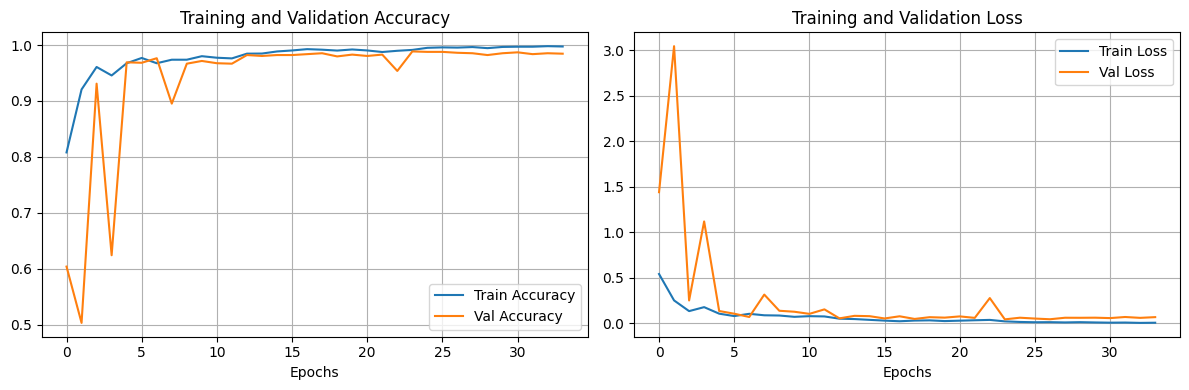

In [124]:
plot_from_history(history_efficientNetB0)

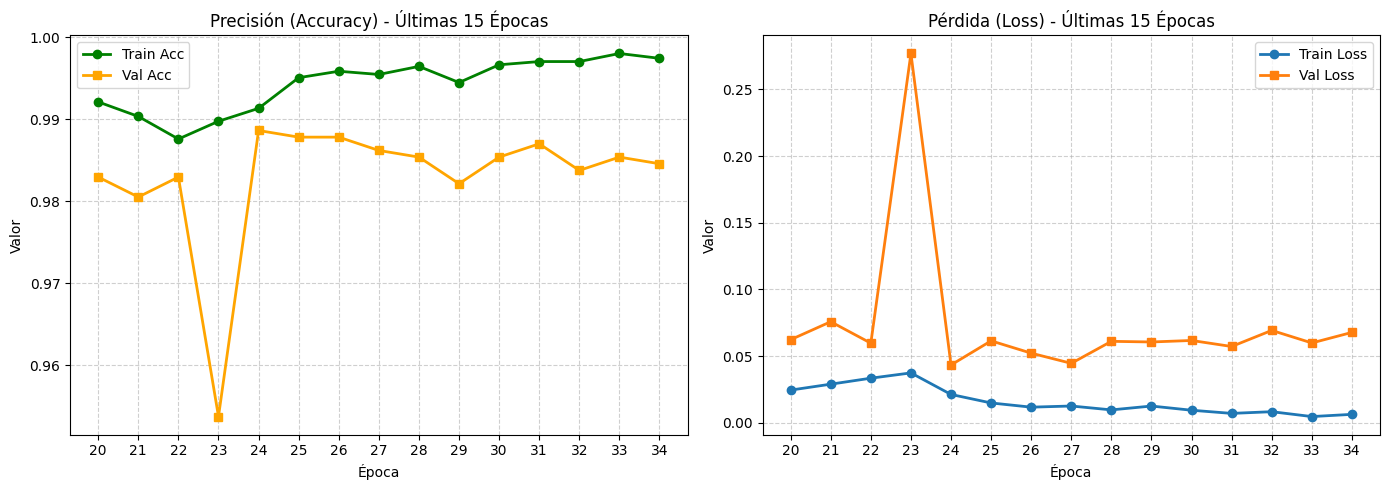

In [126]:
show_last_epochs(history_efficientNetB0, idx = 15)

##### Save model

In [107]:
tf.saved_model.save(model_efficientNetB0, "multiclassModels/model_efficientNetB0")
save_history(history_efficientNetB0, "multiclassHistories/history_efficientNetB0.pkl")

INFO:tensorflow:Assets written to: multiclassModels/model_efficientNetB0\assets


INFO:tensorflow:Assets written to: multiclassModels/model_efficientNetB0\assets


##### Load model

In [ ]:
model_efficientNetB0 = load_model("multiclassModels/model_efficientNetB0")
history_efficientNetB0 = load_history("multiclassHistories/history_efficientNetB0.pkl")

Historial cargado desde multiclassHistories/history_efficientNetB0.pkl.


#### Test

In [127]:
y_pred_efficientNetB0 = model_efficientNetB0.predict(test_ds)
y_pred_classes_efficientNetB0 = y_pred_efficientNetB0.argmax(axis=1)

f1_efficientNetB0 = f1_score(test_labels, y_pred_classes_efficientNetB0, average="weighted")
print(f"F1 Score EfficientNetB0: {f1_efficientNetB0}")
print("-------------------------------------")

print("Classification Report EfficientNetB0:")
print(classification_report(test_labels, y_pred_classes_efficientNetB0, target_names=class_names))

97/97 [==============================] - 4s 27ms/step
F1 Score EfficientNetB0: 0.9817916721836963
-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.96      0.97       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.91      0.91      0.91        47
           soldar       0.98      0.98      0.98       451

         accuracy                           0.98      1540
        macro avg       0.97      0.96      0.96      1540
     weighted avg       0.98      0.98      0.98      1540



In [128]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_efficientNetB0, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1124  | 11    | 15    | 390   |OK
colocarPila          | 901   | 2     | 0     | 637   |OK
colocarSoporteSup    | 1489  | 4     | 4     | 43    |OK
soldar               | 1078  | 11    | 9     | 442   |OK
---------------------------------------------------------------------------


Falsos FN de colocarSoporteSup: 4
=========== Falsos FN de colocarSoporteSup ===========


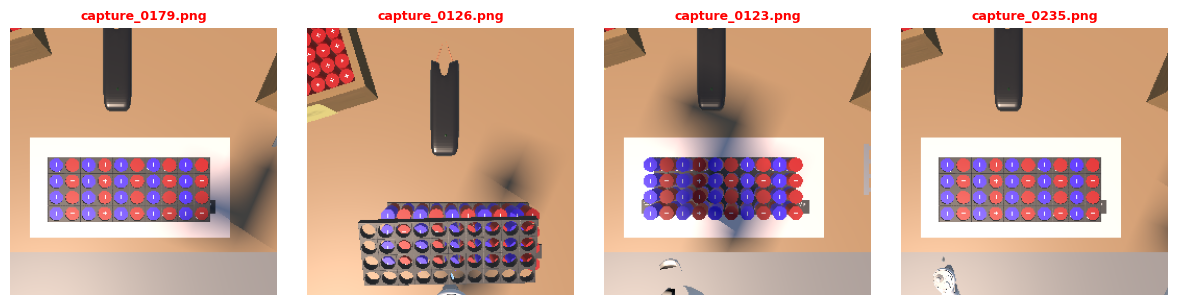

In [115]:
show_false_labels_multiclass(test_labels, test_paths, class_names, y_pred_classes_efficientNetB0, 2, 'FN')

In [ ]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=4e-10
    )

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5*2, 
    verbose=1, 
    restore_best_weights=True
)


history_efficientNetB0_extended = model_efficientNetB0.fit(
        train_ds, 
        epochs=30, 
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

print("\nEvaluando en Entrenamiento...")
train_loss, train_acc = model_efficientNetB0.evaluate(train_ds, verbose=0)
print("Evaluando en Test...")
test_loss, test_acc = model_efficientNetB0.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc}\nTrain accuracy: {train_acc}")
print(f"Test loss: {test_loss}\nTrain loss: {train_loss}")

Epoch 1/30
308/308 [==============================] - 34s 109ms/step - loss: 0.0166 - accuracy: 0.9933 - val_loss: 0.0489 - val_accuracy: 0.9846 - lr: 6.2500e-04
Epoch 2/30
308/308 [==============================] - 33s 109ms/step - loss: 0.0209 - accuracy: 0.9937 - val_loss: 0.0439 - val_accuracy: 0.9862 - lr: 6.2500e-04
Epoch 3/30
308/308 [==============================] - 34s 109ms/step - loss: 0.0147 - accuracy: 0.9945 - val_loss: 0.0573 - val_accuracy: 0.9838 - lr: 6.2500e-04
Epoch 4/30
308/308 [==============================] - 34s 109ms/step - loss: 0.0143 - accuracy: 0.9939 - val_loss: 0.0471 - val_accuracy: 0.9846 - lr: 6.2500e-04
Epoch 5/30
308/308 [==============================] - 34s 110ms/step - loss: 0.0114 - accuracy: 0.9951 - val_loss: 0.0607 - val_accuracy: 0.9846 - lr: 6.2500e-04
Epoch 6/30
308/308 [==============================] - 34s 109ms/step - loss: 0.0101 - accuracy: 0.9963 - val_loss: 0.0672 - val_accuracy: 0.9838 - lr: 6.2500e-04
Epoch 7/30
308/308 [========

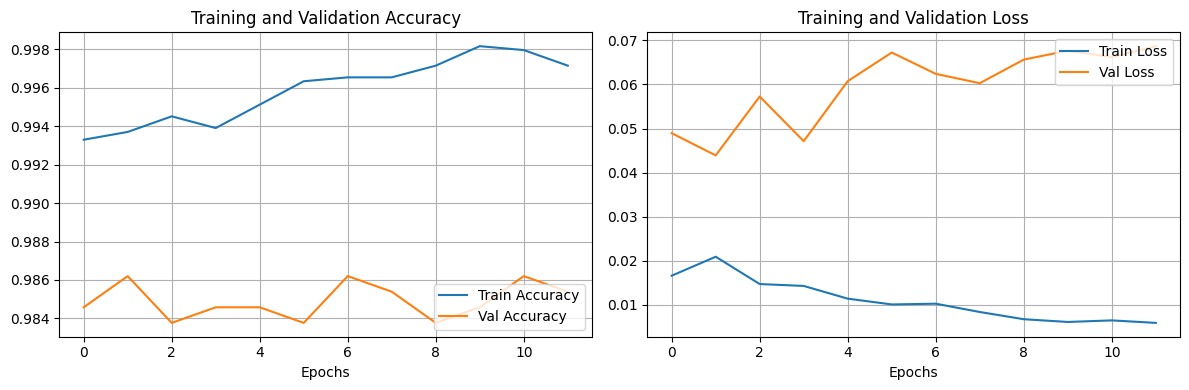

In [118]:
plot_from_history(history_efficientNetB0_extended)

In [119]:
y_pred_efficientNetB0 = model_efficientNetB0.predict(test_ds)
y_pred_classes_efficientNetB0 = y_pred_efficientNetB0.argmax(axis=1)

f1_efficientNetB0 = f1_score(test_labels, y_pred_classes_efficientNetB0, average="weighted")
print(f"F1 Score EfficientNetB0: {f1_efficientNetB0}")
print("-------------------------------------")

print("Classification Report EfficientNetB0:")
print(classification_report(test_labels, y_pred_classes_efficientNetB0, target_names=class_names))

97/97 [==============================] - 3s 27ms/step
F1 Score EfficientNetB0: 0.9824562903367234
-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.97      0.97       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.98      0.91      0.95        47
           soldar       0.98      0.98      0.98       451

         accuracy                           0.98      1540
        macro avg       0.98      0.97      0.97      1540
     weighted avg       0.98      0.98      0.98      1540



In [120]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_efficientNetB0, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1121  | 14    | 11    | 394   |OK
colocarPila          | 902   | 1     | 3     | 634   |OK
colocarSoporteSup    | 1492  | 1     | 4     | 43    |OK
soldar               | 1078  | 11    | 9     | 442   |OK
---------------------------------------------------------------------------


### MobileNet

In [121]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import mobilenet

In [139]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, 32, 'neg1_1', False)

In [ ]:
batch_size = 32

# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
           # .flat_map(augment_if_minority)
           # .shuffle(buffer_size=1000)  
            .map(lambda x, y: (mobilenet.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
            .map(lambda x, y: (mobilenet.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
            .map(lambda x, y: (mobilenet.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

In [140]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_mobilenet = Sequential([
    base_mobilenet,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

# base_mobilenet.trainable = False
# inputs = tf.keras.Input(shape=(256, 256, 3))
# # We make sure that the base_model is running in inference mode here,
# # by passing `training=False`. This is important for fine-tuning, as you will
# # learn in a few paragraphs.
# x = base_mobilenet(inputs, training=False)
# # Convert features of shape `base_model.output_shape[1:]` to vectors
# outputs = layers.Dense(4, activation='softmax')(x)
# model_mobilenet = tf.keras.Model(inputs, outputs)

epochs=20
test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_mobilenet = training_pipeline(model_mobilenet, train_ds, val_ds, test_ds, patience =3, epochs=epochs, lr = 0.0001, dict_weights=None)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/20
154/154 [==============================] - 18s 99ms/step - loss: 0.4861 - accuracy: 0.8100 - val_loss: 1.8303 - val_accuracy: 0.4140 - lr: 1.0000e-04
Epoch 2/20
154/154 [==============================] - 14s 92ms/step - loss: 0.1198 - accuracy: 0.9625 - val_loss: 2.9999 - val_accuracy: 0.4140 - lr: 1.0000e-04
Epoch 3/20
154/154 [==============================] - 14s 94ms/step - loss: 0.0873 - accuracy: 0.9730 - val_loss: 3.5426 - val_accuracy: 0.4140 - lr: 1.0000e-04
Epoch 4/20
154/154 [==============================] - ETA: 0s - loss: 0.0550 - accuracy: 0.9848
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
154/154 [==============================] - 15s 94ms/step - loss: 0.0550 - accuracy: 0.9848 - val_loss: 1.9502 - val_accuracy: 0.4140 - lr: 1.0000e-04
Epoch 5/20
154/154 [==============================] - 15s 95ms/step - loss: 0.0451 - accuracy: 0.9880 - val_loss: 0.7777 - val_accuracy: 0.7175 - lr: 5.0000e-05
Epoch 6/20
154/154 [==============

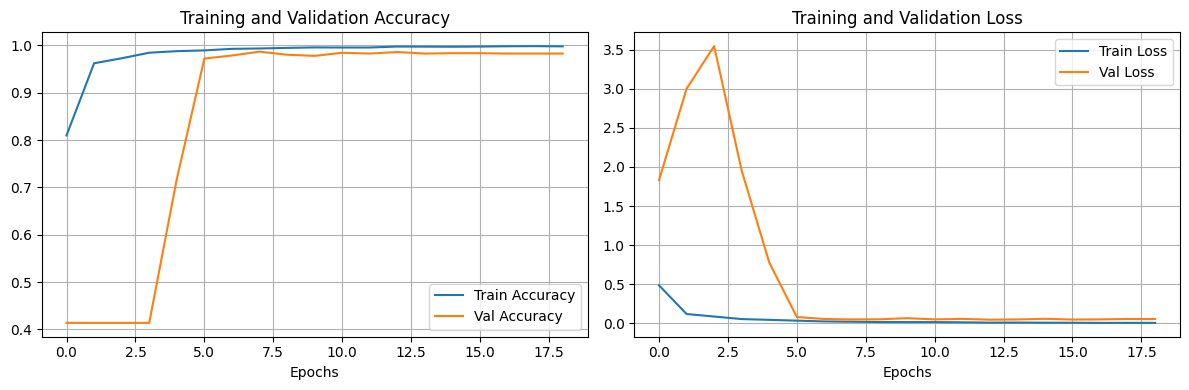

In [141]:
plot_from_history(history_mobilenet)

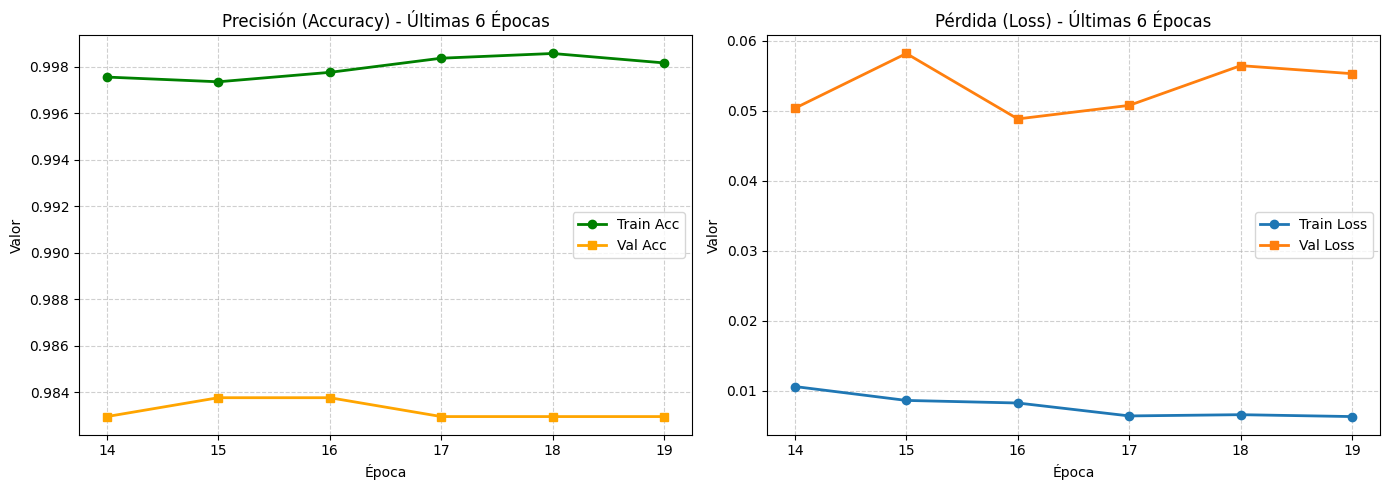

In [142]:
show_last_epochs(history_mobilenet, idx = 6)

In [33]:
model_mobilenet.save("multiclassModels\model_mobilenet.h5")
save_history(history_mobilenet, "multiclassHistories\history_mobilenet.pkl")

In [ ]:
model_mobilenet = load_model("multiclassModels\model_mobilenet.h5")
history_mobilenet = load_history("multiclassHistories\history_mobilenet.pkl")

Historial cargado desde history_mobilenet.pkl.


In [143]:
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

49/49 [==============================] - 2s 31ms/step
F1 Score MobileNet: 0.9773291690470087
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.96      0.97      0.96       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.88      0.89      0.88        47
           soldar       0.98      0.97      0.97       451

         accuracy                           0.98      1540
        macro avg       0.95      0.96      0.95      1540
     weighted avg       0.98      0.98      0.98      1540



In [144]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1117  | 18    | 13    | 392   |OK
colocarPila          | 901   | 2     | 3     | 634   |OK
colocarSoporteSup    | 1487  | 6     | 5     | 42    |OK
soldar               | 1080  | 9     | 14    | 437   |OK
---------------------------------------------------------------------------


Falsos FP de colocarSoporteSup: 17
=========== Falsos FP de colocarSoporteSup ===========


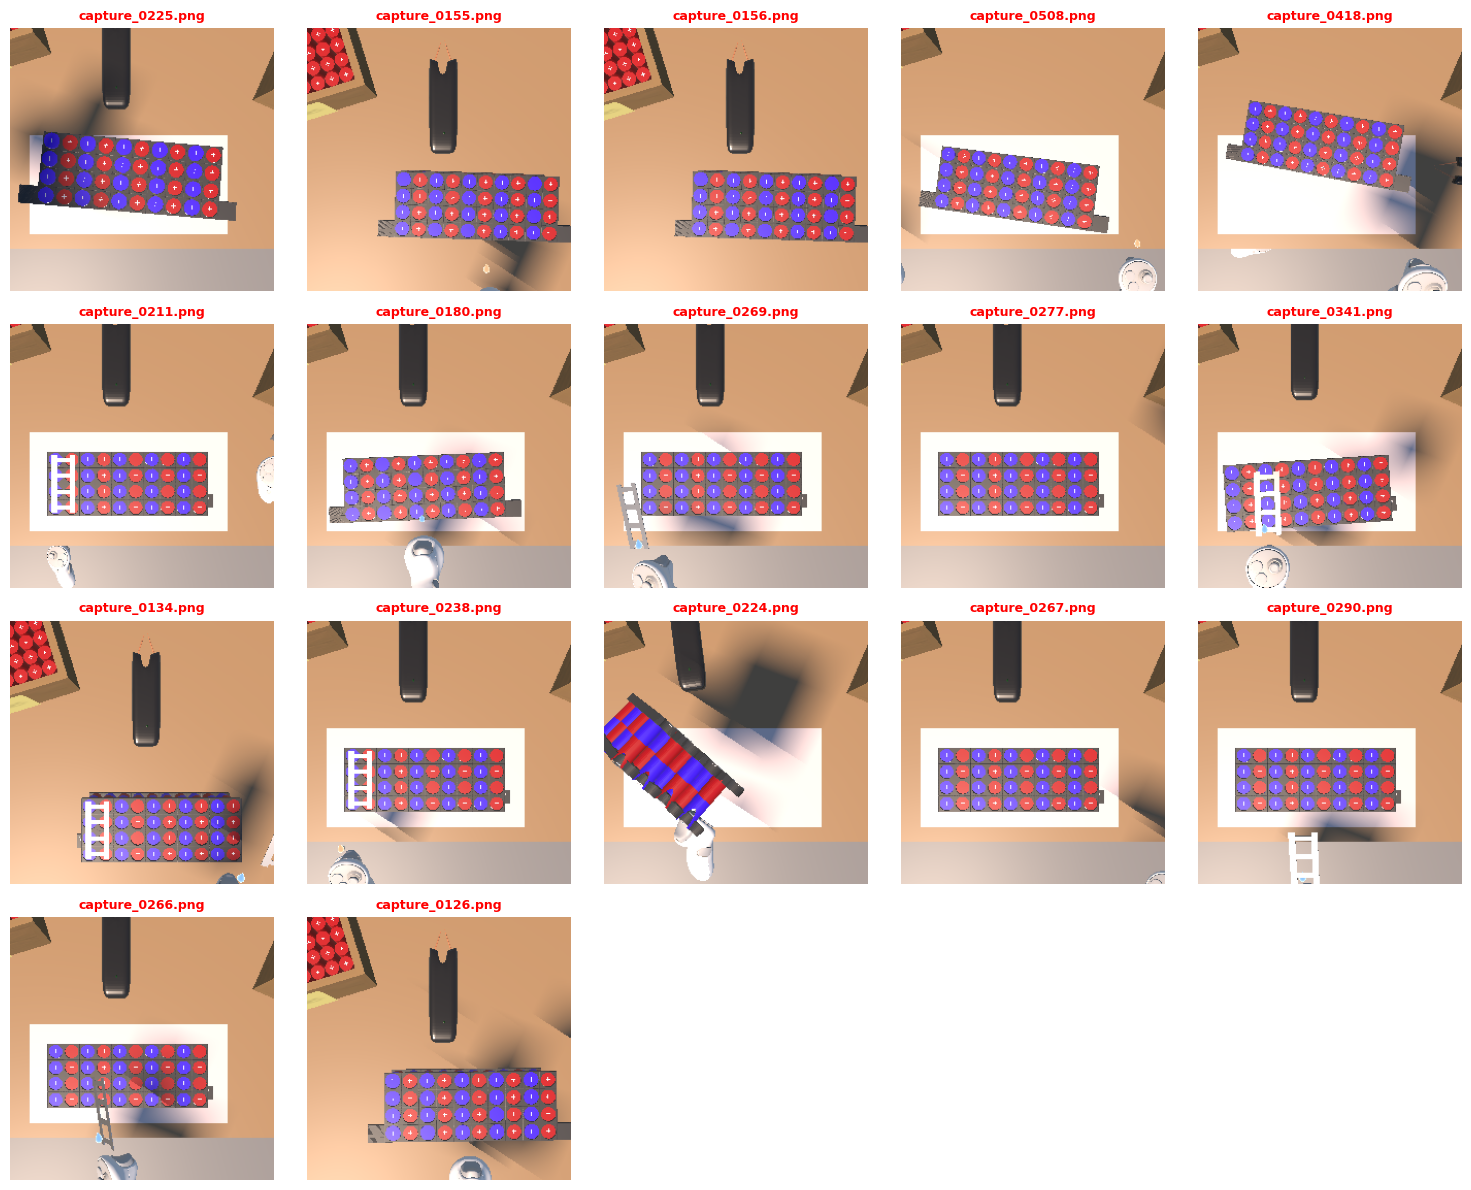

In [26]:
show_false_labels_multiclass(test_labels, test_paths, class_names, y_pred_classes_mobilenet, 2, type='FP') 

In [145]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=4e-10
    )

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5*2, 
    verbose=1, 
    restore_best_weights=True
)


history_mobilenet_extended = model_mobilenet.fit(
        train_ds, 
        epochs=30, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

print("\nEvaluando en Entrenamiento...")
train_loss, train_acc = model_mobilenet.evaluate(train_ds, verbose=0)
print("Evaluando en Test...")
test_loss, test_acc = model_mobilenet.evaluate(test_ds, verbose=0)



Epoch 1/30
154/154 [==============================] - 16s 95ms/step - loss: 0.0100 - accuracy: 0.9982 - val_loss: 0.0536 - val_accuracy: 0.9846 - lr: 6.2500e-06
Epoch 2/30
154/154 [==============================] - 14s 94ms/step - loss: 0.0106 - accuracy: 0.9974 - val_loss: 0.0467 - val_accuracy: 0.9854 - lr: 6.2500e-06
Epoch 3/30
154/154 [==============================] - 15s 94ms/step - loss: 0.0099 - accuracy: 0.9974 - val_loss: 0.0465 - val_accuracy: 0.9846 - lr: 6.2500e-06
Epoch 4/30
154/154 [==============================] - 15s 95ms/step - loss: 0.0071 - accuracy: 0.9978 - val_loss: 0.0440 - val_accuracy: 0.9854 - lr: 6.2500e-06
Epoch 5/30
154/154 [==============================] - 15s 94ms/step - loss: 0.0073 - accuracy: 0.9986 - val_loss: 0.0472 - val_accuracy: 0.9821 - lr: 6.2500e-06
Epoch 6/30
154/154 [==============================] - 15s 95ms/step - loss: 0.0067 - accuracy: 0.9976 - val_loss: 0.0419 - val_accuracy: 0.9830 - lr: 6.2500e-06
Epoch 7/30
154/154 [==============

In [146]:
print(f"Test accuracy: {test_acc}\nTrain accuracy: {train_acc}")
print(f"Test loss: {test_loss}\nTrain loss: {train_loss}")

Test accuracy: 0.981168806552887
Train accuracy: 0.9989851713180542
Test loss: 0.05759626626968384
Train loss: 0.0027600161265581846


In [147]:
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

49/49 [==============================] - 1s 28ms/step
F1 Score MobileNet: 0.9811688311688311
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.97      0.97       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.89      0.89      0.89        47
           soldar       0.98      0.98      0.98       451

         accuracy                           0.98      1540
        macro avg       0.96      0.96      0.96      1540
     weighted avg       0.98      0.98      0.98      1540



In [148]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1122  | 13    | 13    | 392   |OK
colocarPila          | 901   | 2     | 2     | 635   |OK
colocarSoporteSup    | 1488  | 5     | 5     | 42    |OK
soldar               | 1080  | 9     | 9     | 442   |OK
---------------------------------------------------------------------------


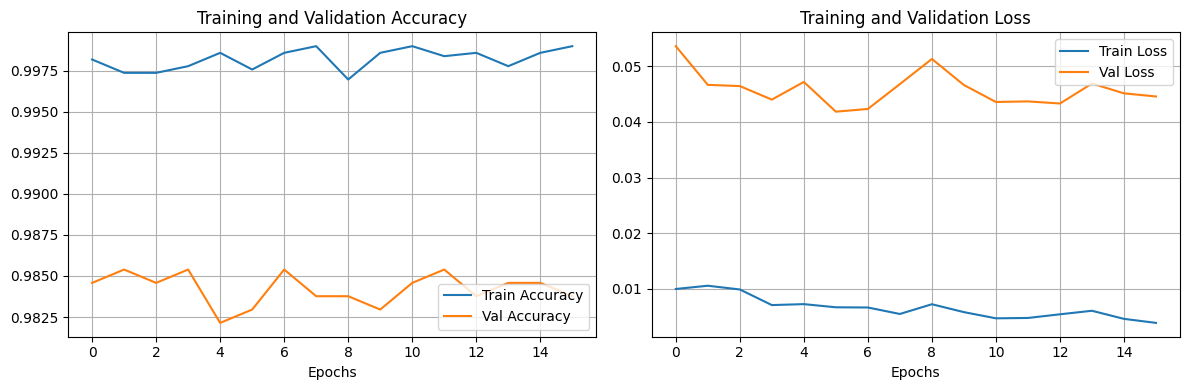

In [149]:
plot_from_history(history_mobilenet_extended)

In [40]:
model_mobilenet.save("multiclassModels\model_mobilenet.h5")
save_history(history_mobilenet_extended, "multiclassHistories\history_mobilenet.pkl")

In [35]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=4e-10
    )

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5*2, 
    verbose=1, 
    restore_best_weights=True
)


history_mobilenet_extended = model_mobilenet.fit(
        train_ds, 
        epochs=30, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

print("\nEvaluando en Entrenamiento...")
train_loss, train_acc = model_mobilenet.evaluate(train_ds, verbose=0)
print("Evaluando en Test...")
test_loss, test_acc = model_mobilenet.evaluate(test_ds, verbose=0)



Epoch 1/30
159/159 [==============================] - 9s 51ms/step - loss: 0.0767 - accuracy: 0.9821 - val_loss: 0.0937 - val_accuracy: 0.9756 - lr: 1.0000e-04
Epoch 2/30
159/159 [==============================] - 9s 51ms/step - loss: 0.0755 - accuracy: 0.9821 - val_loss: 0.0942 - val_accuracy: 0.9748 - lr: 1.0000e-04
Epoch 3/30
159/159 [==============================] - 9s 51ms/step - loss: 0.0747 - accuracy: 0.9827 - val_loss: 0.0895 - val_accuracy: 0.9748 - lr: 1.0000e-04
Epoch 4/30
159/159 [==============================] - 9s 51ms/step - loss: 0.0729 - accuracy: 0.9835 - val_loss: 0.0937 - val_accuracy: 0.9708 - lr: 1.0000e-04
Epoch 5/30
159/159 [==============================] - 9s 49ms/step - loss: 0.0716 - accuracy: 0.9837 - val_loss: 0.0875 - val_accuracy: 0.9748 - lr: 1.0000e-04
Epoch 6/30
159/159 [==============================] - 9s 50ms/step - loss: 0.0711 - accuracy: 0.9831 - val_loss: 0.0874 - val_accuracy: 0.9756 - lr: 1.0000e-04
Epoch 7/30
159/159 [====================

In [36]:
print(f"Test accuracy: {test_acc}\nTrain accuracy: {train_acc}")
print(f"Test loss: {test_loss}\nTrain loss: {train_loss}")

Test accuracy: 0.984415590763092
Train accuracy: 0.9923213124275208
Test loss: 0.057353392243385315
Train loss: 0.040821194648742676


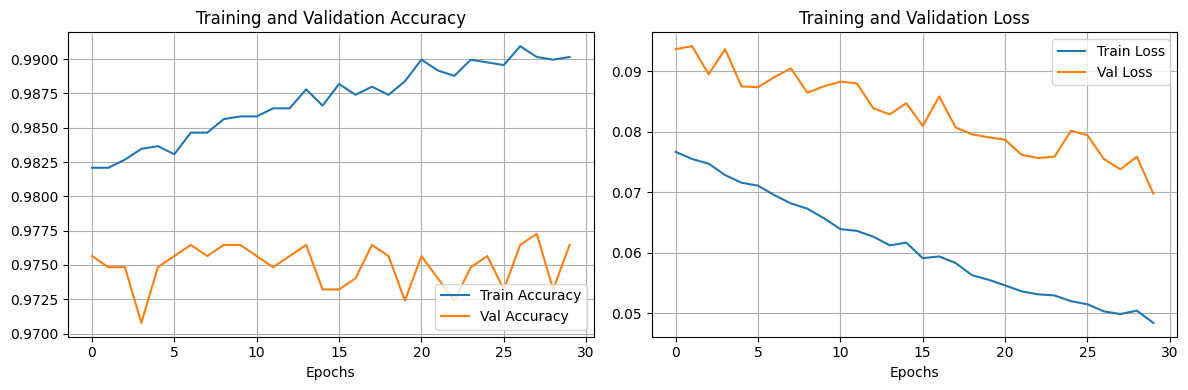

In [37]:
plot_from_history(history_mobilenet_extended)

In [38]:
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

49/49 [==============================] - 2s 35ms/step
F1 Score MobileNet: 0.9844119983793722
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.98      0.97      0.97       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.94      0.96      0.95        47
           soldar       0.98      0.98      0.98       451

         accuracy                           0.98      1540
        macro avg       0.97      0.98      0.97      1540
     weighted avg       0.98      0.98      0.98      1540



In [39]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1125  | 10    | 13    | 392   |OK
colocarPila          | 902   | 1     | 0     | 637   |OK
colocarSoporteSup    | 1490  | 3     | 2     | 45    |OK
soldar               | 1079  | 10    | 9     | 442   |OK
---------------------------------------------------------------------------


In [41]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=4e-10
    )

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5*2, 
    verbose=1, 
    restore_best_weights=True
)


history_mobilenet_extended = model_mobilenet.fit(
        train_ds, 
        epochs=50, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

print("\nEvaluando en Entrenamiento...")
train_loss, train_acc = model_mobilenet.evaluate(train_ds, verbose=0)
print("Evaluando en Test...")
test_loss, test_acc = model_mobilenet.evaluate(test_ds, verbose=0)

print(f"Test accuracy: {test_acc}\nTrain accuracy: {train_acc}")
print(f"Test loss: {test_loss}\nTrain loss: {train_loss}")

Epoch 1/50
159/159 [==============================] - 9s 51ms/step - loss: 0.0479 - accuracy: 0.9905 - val_loss: 0.0738 - val_accuracy: 0.9756 - lr: 1.0000e-04
Epoch 2/50
159/159 [==============================] - 9s 50ms/step - loss: 0.0476 - accuracy: 0.9904 - val_loss: 0.0717 - val_accuracy: 0.9740 - lr: 1.0000e-04
Epoch 3/50
159/159 [==============================] - 9s 49ms/step - loss: 0.0463 - accuracy: 0.9915 - val_loss: 0.0703 - val_accuracy: 0.9765 - lr: 1.0000e-04
Epoch 4/50
159/159 [==============================] - 9s 49ms/step - loss: 0.0455 - accuracy: 0.9905 - val_loss: 0.0695 - val_accuracy: 0.9765 - lr: 1.0000e-04
Epoch 5/50
159/159 [==============================] - 9s 49ms/step - loss: 0.0450 - accuracy: 0.9921 - val_loss: 0.0725 - val_accuracy: 0.9732 - lr: 1.0000e-04
Epoch 6/50
159/159 [==============================] - 9s 49ms/step - loss: 0.0452 - accuracy: 0.9909 - val_loss: 0.0695 - val_accuracy: 0.9748 - lr: 1.0000e-04
Epoch 7/50
159/159 [====================

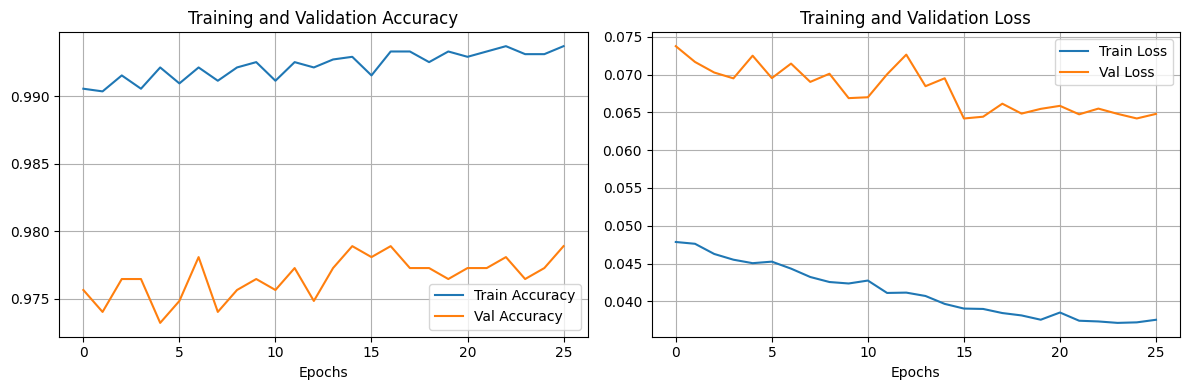

In [42]:
plot_from_history(history_mobilenet_extended)

In [43]:
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

show_multiclass_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

49/49 [==============================] - 1s 30ms/step
F1 Score MobileNet: 0.9857099604778577
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.98      0.97       405
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.96      0.96      0.96        47
           soldar       0.98      0.98      0.98       451

         accuracy                           0.99      1540
        macro avg       0.98      0.98      0.98      1540
     weighted avg       0.99      0.99      0.99      1540

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1124  | 11    | 10    | 395   |OK
colocarPila          | 902   | 1     | 0     | 637   |OK
colocarSoporteSup    | 1491  | 2     | 2     | 45    |OK
sol

### VGG16

In [150]:
from tensorflow.keras.applications import vgg16

In [159]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, batch_size=16, norm_method='0_1', augment_minority=False)

In [161]:
batch_size = 16

# --- DATASET DE ENTRENAMIENTO ---
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths))
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(lambda x, y: (vgg16.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --- DATASET DE VALIDACIÓN ---
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(lambda x, y: (vgg16.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --- DATASET DE TEST ---
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(lambda x, y: (vgg16.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))


In [162]:
start_time = time.time()

base_vgg16 = vgg16.VGG16(
    include_top = False,
    weights = 'imagenet',
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_vgg16 = Sequential([
    base_vgg16,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_vgg16, train_acc_vgg16, train_loss_vgg16, test_loss_vgg16, history_vgg16 = training_pipeline(model_vgg16, train_ds, val_ds, test_ds, epochs=epochs, patience = 3, lr=0.005, dict_weights=None)
print(f"Test accuracy: {test_acc_vgg16}\nTrain accuracy: {train_acc_vgg16}")
print(f"Test loss: {test_loss_vgg16}\nTrain loss: {train_loss_vgg16}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

58889256/58889256 [==============================] - 3s 0us/step
Epoch 1/10
308/308 [==============================] - 55s 174ms/step - loss: 267848.3750 - accuracy: 0.3653 - val_loss: 1.1835 - val_accuracy: 0.4140 - lr: 0.0050
Epoch 2/10
308/308 [==============================] - 54s 175ms/step - loss: 1.2744 - accuracy: 0.3984 - val_loss: 1.1886 - val_accuracy: 0.4140 - lr: 0.0050
Epoch 3/10
308/308 [==============================] - 55s 177ms/step - loss: 1.1906 - accuracy: 0.4134 - val_loss: 1.1841 - val_accuracy: 0.4140 - lr: 0.0050
Epoch 4/10
308/308 [==============================] - 55s 177ms/step - loss: 1.1856 - accuracy: 0.4134 - val_loss: 1.1834 - val_accuracy: 0.4140 - lr: 0.0050
Epoch 5/10
308/308 [==============================] - 55s 177ms/step - loss: 1.1843 - accuracy: 0.4134 - val_loss: 1.1842 - val_accuracy: 0.4140 - lr: 0.0050
Epoch 6/10
308/308 [==============================] - 55s 177ms/step - loss: 1.1844 - accuracy: 0.4134 - val_loss: 1.1831 - val_accuracy: 0.

In [29]:
model_vgg16.save("multiclassModels\modelo_vgg16.h5")
save_history(history_vgg16, "multiclassHistories\history_vgg16.pkl")

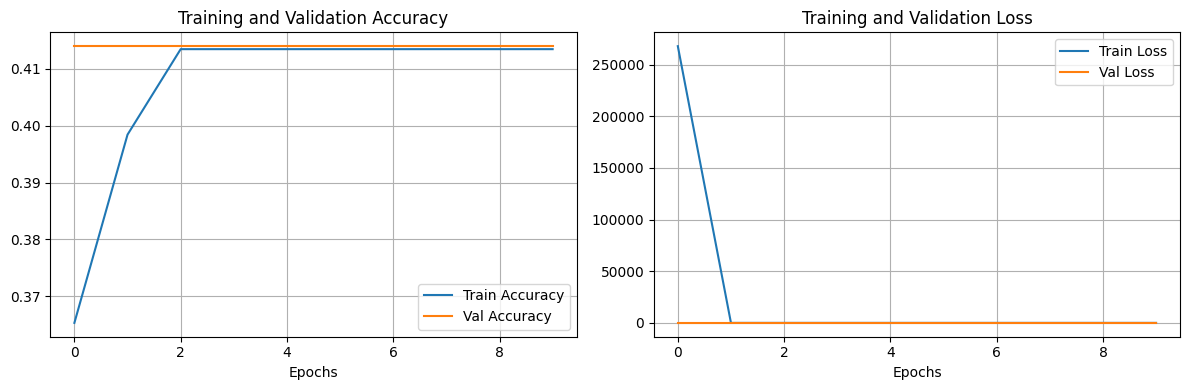

In [163]:
plot_from_history(history_vgg16)

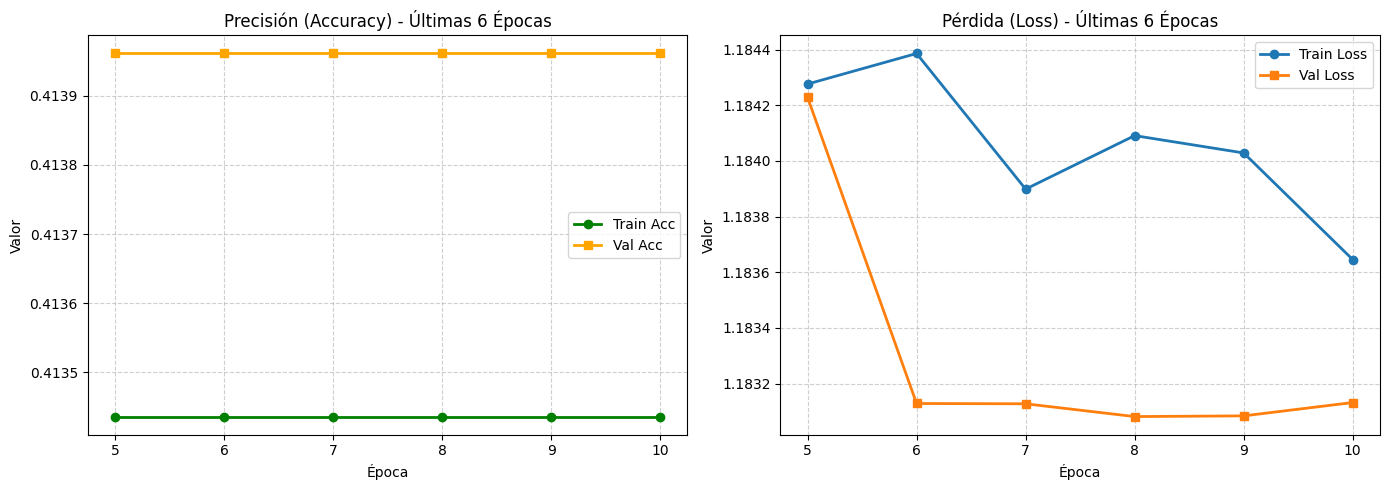

In [164]:
show_last_epochs(history_vgg16, idx = 6)

In [165]:
y_pred_vgg16 = model_vgg16.predict(test_ds)
y_pred_classes_vgg16 = y_pred_vgg16.argmax(axis=1)
class_names = encoder.classes_ 

f1_vgg16 = f1_score(test_labels, y_pred_classes_vgg16, average="weighted")
print(f"F1 Score vgg16: {f1_vgg16}")
print("-------------------------------------")

print("Classification Report vgg16:")
print(classification_report(test_labels, y_pred_classes_vgg16, target_names=class_names))

97/97 [==============================] - 4s 44ms/step
F1 Score vgg16: 0.2420637240572932
-------------------------------------
Classification Report vgg16:
                   precision    recall  f1-score   support

    colocarNiquel       0.00      0.00      0.00       405
      colocarPila       0.41      1.00      0.59       637
colocarSoporteSup       0.00      0.00      0.00        47
           soldar       0.00      0.00      0.00       451

         accuracy                           0.41      1540
        macro avg       0.10      0.25      0.15      1540
     weighted avg       0.17      0.41      0.24      1540



c:\Users\marci\miniconda3\envs\tfm_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\marci\miniconda3\envs\tfm_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\marci\miniconda3\envs\tfm_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

In [166]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_vgg16, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1135  | 0     | 405   | 0     | >25%
colocarPila          | 0     | 903   | 0     | 637   | >25%
colocarSoporteSup    | 1493  | 0     | 47    | 0     | >25%
soldar               | 1089  | 0     | 451   | 0     | >25%
---------------------------------------------------------------------------


## SVMs
SVC, NuSVC and LinearSVC are classes capable of performing binary and multi-class classification on a dataset.

In [85]:
def prepare_data_for_svm(paths, labels, size=(256, 256), gray=False):
    x = []
    y = []
    
    for path, label in zip(paths, labels):
        img = cv2.imread(path)
        if gray:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises
        img = cv2.resize(img, size)
        x.append(img.flatten())  # Aplanar la imagen a un vector
        y.append(label)  # Obtener la etiqueta correspondiente

    x = np.array(x) / 255.0
    
    return np.array(x), np.array(y)

In [82]:
(paths, labels), encoder = get_paths_and_labels(df, split=False)

In [83]:
class_names = encoder.classes_

In [86]:
x, y = prepare_data_for_svm(paths, labels, size=(170, 170), gray=True)

### SVC 
C-Support Vector Classification.


In [40]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV 
from sklearn.decomposition import PCA

- C: Controls the trade-off between a wider margin (low C) and correctly classifying all points (high C).
- gamma: Controls the influence of data points. High gamma leads to a tight boundary and may cause overfitting.
- kernel: Defines the function used to transform data for separating classes. 





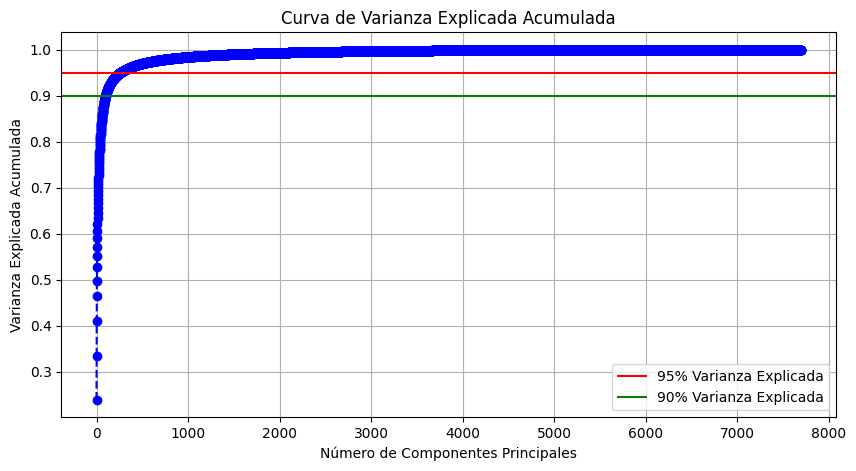

Para retener el 95% de la varianza necesitas: 260 componentes.


In [ ]:
pca_full = PCA().fit(x)

variance_cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(variance_cumsum, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Varianza Explicada')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Varianza Explicada')

plt.title('Curva de Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.legend()
plt.show()

components_95 = np.argmax(variance_cumsum >= 0.95) + 1
print(f"Para retener el 95% de la varianza necesitas: {components_95} componentes.")

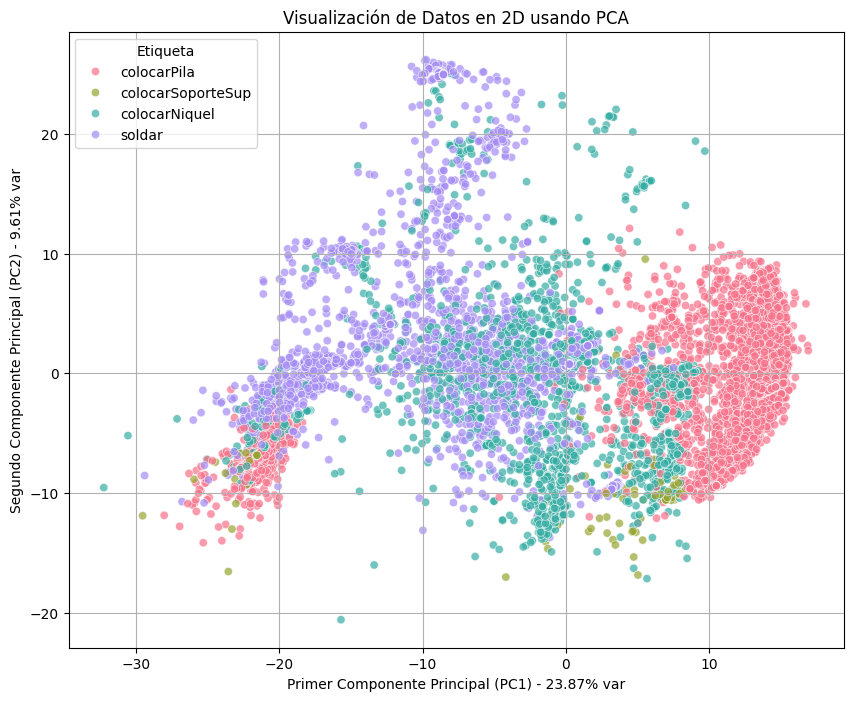

In [94]:
# PCA con dos componentes para graficar
pca_2d = PCA(n_components=2)
x_train_pca_2d = pca_2d.fit_transform(x)

df_pca = pd.DataFrame(x_train_pca_2d, columns=['PC1', 'PC2'])
df_pca['Etiqueta'] = class_names[y]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Etiqueta', 
    palette='husl',  
    data=df_pca, 
    alpha=0.7
)

# porcentajes de varianza que representan esos dos ejes
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

plt.title('Visualización de Datos en 2D usando PCA')
plt.xlabel(f'Primer Componente Principal (PC1) - {var_pc1:.2f}% var')
plt.ylabel(f'Segundo Componente Principal (PC2) - {var_pc2:.2f}% var')
plt.grid(True)
plt.show()

In [88]:
x_pca = PCA(n_components=260).fit_transform(x)

In [89]:
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)

In [90]:
param_grid = {'C': [0.1, 1, 10, 100], 
			'gamma': [0.01, 0.001, 0.0001], 
			'kernel': ['rbf']} 

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3, n_jobs=-1) 
 
grid.fit(x_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [91]:
y_pred_svm = grid.predict(x_test)

f1_svm = f1_score(y_test, y_pred_svm, average="weighted")
print(f"F1 Score SVM: {f1_svm}")
print("-------------------------------------")

print("Classification Report SVM:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

F1 Score SVM: 0.9830830740581794
-------------------------------------
Classification Report SVM:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.97      0.97       422
      colocarPila       1.00      1.00      1.00       617
colocarSoporteSup       0.94      0.91      0.93        55
           soldar       0.98      0.98      0.98       446

         accuracy                           0.98      1540
        macro avg       0.97      0.97      0.97      1540
     weighted avg       0.98      0.98      0.98      1540



In [92]:
show_multiclass_confusion_matrix(y_test, y_pred_svm, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1106  | 12    | 11    | 411   |OK
colocarPila          | 920   | 3     | 3     | 614   |OK
colocarSoporteSup    | 1482  | 3     | 5     | 50    |OK
soldar               | 1086  | 8     | 7     | 439   |OK
---------------------------------------------------------------------------


In [93]:
joblib.dump(grid, "multiclassModels\modelo_svm.pkl")

['multiclassModels\\modelo_svm.pkl']

In [ ]:
historial_svm = pd.DataFrame(grid.cv_results_)

historial_svm = historial_svm.sort_values(by='mean_test_score', ascending=False)

columnas_interes = ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'mean_fit_time']
print(historial_svm[columnas_interes].head())

    param_C  param_gamma  mean_test_score  std_test_score  mean_fit_time
8      10.0       0.0001         0.511610        0.002764      31.459429
11    100.0       0.0001         0.511610        0.002764      30.849387
5       1.0       0.0001         0.509012        0.003021      30.527184
7      10.0       0.0010         0.496023        0.003579      31.175892
10    100.0       0.0010         0.496023        0.003579      30.930669


### Multimodal data

In [ ]:
coord_paths = [ os.path.join(sess, "coordenadas.txt") for sess in imgs]
coord_paths = [ os.path.join(path_capturasVR, coord_path) for coord_path in coord_paths]
print(coord_paths)

['../capturas/capturas_256x256/capturasVR\\Session_001\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_002\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_003\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_004\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_005\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_006\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_007\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_008\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_009\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_010\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_011\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_012\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_013\\coordenadas.txt', '../capturas/capturas_256x256/capturasVR\\Session_

In [21]:
def clean_block(hand_coords):

    aux = hand_coords.split(',')

    if len(aux) == 6:
        x = f"{aux[0]}.{aux[1]}"
        y = f"{aux[2]}.{aux[3]}"
        z = f"{aux[4]}.{aux[5]}"

    elif len(aux) == 3:
        x, y, z = aux

    else:
        return [0.0, 0.0, 0.0]

    return [float(x), float(y), float(z)]


In [25]:
columnas_csv = ['id_captura', 'time', 'left_x', 'left_y', 'left_z', 'right_x', 'right_y', 'right_z']
regex_manos = r"\((.*?)\)"
csv_coord_paths = []

for txt_path in coord_paths:
    folder_path = os.path.dirname(txt_path)
    csv_path = os.path.join(folder_path, "coordenadas.csv")
    print(f"Procesando: {txt_path}")
    csv_coord_paths.append(csv_path)
    datos_csv = []

    with open(txt_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for id_line, line in enumerate(lines):
        line = line.strip()

        parts = line.split()

        timestamp = parts[0]

        rest = "".join(parts[1:])

        hand_coords = re.findall(regex_manos,rest)

        left_coords = clean_block(hand_coords[0])
        right_coords = clean_block(hand_coords[1])


        fila = [id_line, timestamp] + left_coords + right_coords
        datos_csv.append(fila)

    df_sesion = pd.DataFrame(datos_csv, columns=columnas_csv)
    df_sesion.to_csv(csv_path, index=False)

Procesando: ../capturas/capturas_256x256/capturasVR\Session_001\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_002\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_003\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_004\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_005\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_006\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_007\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_008\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_009\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_010\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_011\coordenadas.txt
Procesando: ../capturas/capturas_256x256/capturasVR\Session_012\coordenadas.txt
Procesando: ../capturas/capturas_256x256

In [ ]:
left_x, left_y, left_z = [], [], []
right_x, right_y, right_z = [], [], []
cache_csv_sesiones = {}

for idx, line in df.iterrows():
    filename = line['filename']
    session = line['session']

    name = filename.split("/")[-1]
    id_captura = int(''.join(filter(str.isdigit, name)))

    if session not in cache_csv_sesiones:
        csv_session_path = os.path.join(path_capturasVR, session, "coordenadas.csv")

        if os.path.exists(csv_session_path):
            df_coords = pd.read_csv(csv_session_path).set_index('id_captura')
            cache_csv_sesiones[session] = df_coords
        else:
            cache_csv_sesiones[session] = None
            print(f"  [!] Advertencia: No se encontró {csv_session_path}")

    df_coords_actual = cache_csv_sesiones[session]

    if df_coords_actual is not None and id_captura in df_coords_actual.index:
        fila_coords = df_coords_actual.loc[id_captura]
        
        left_x.append(fila_coords['left_x'])
        left_y.append(fila_coords['left_y'])
        left_z.append(fila_coords['left_z'])
        right_x.append(fila_coords['right_x'])
        right_y.append(fila_coords['right_y'])
        right_z.append(fila_coords['right_z'])


df_multimodal = df.copy()

df_multimodal['left_x'] = left_x
df_multimodal['left_y'] = left_y
df_multimodal['left_z'] = left_z
df_multimodal['right_x'] = right_x
df_multimodal['right_y'] = right_y
df_multimodal['right_z'] = right_z

output_path = "../Capturas/Capturas_256x256/CapturasVR/dataset_multimodal_final.csv"
df_multimodal.to_csv(output_path, index=False)

In [35]:
print(df_multimodal[['session', 'filename', 'label', 'left_x', 'left_y', 'left_z', 'right_x', 'right_y', 'right_z']].head())

       session                      filename        label  left_x  left_y  \
0  Session_001  Session_001/capture_0000.png  colocarPila    0.02   -0.55   
1  Session_001  Session_001/capture_0001.png  colocarPila    0.02   -0.55   
2  Session_001  Session_001/capture_0002.png  colocarPila    0.02   -0.55   
3  Session_001  Session_001/capture_0003.png  colocarPila    0.02   -0.57   
4  Session_001  Session_001/capture_0004.png  colocarPila    0.02   -0.56   

   left_z  right_x  right_y  right_z  
0    0.09     0.10    -0.55     0.03  
1    0.09     0.10    -0.54     0.02  
2    0.09    -0.05    -0.33     0.01  
3    0.10    -0.02    -0.30     0.06  
4    0.09     0.21    -0.21    -0.09  


In [36]:
from sklearn.preprocessing import StandardScaler

def prepare_multimodal_data_for_svm(df, base_path, size=(170, 170), gray=True):
    x_images = []
    x_coords = []
    y = []

    columnas_coords = ['left_x', 'left_y', 'left_z', 'right_x', 'right_y', 'right_z']

    for idx, row in df.iterrows():

        img_path = os.path.join(base_path, row['filename'])
        
        img = cv2.imread(img_path)
            
        if gray:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, size)
        
        x_images.append(img.flatten())
        
        coords = row[columnas_coords].values.astype(float)
        x_coords.append(coords)
        
        y.append(row['label'])
        
    x_images = np.array(x_images, dtype=np.float32)
    x_coords = np.array(x_coords, dtype=np.float32)
    y = np.array(y)

    x_imgs_scaled = x_images / 255.0
    scaler = StandardScaler()
    x_coords_scaled = scaler.fit_transform(x_coords)

    X_multimodal = np.hstack((x_imgs_scaled, x_coords_scaled))

    return X_multimodal, y


In [42]:
X_multimodal, y_multimodal = prepare_multimodal_data_for_svm(
    df=df_multimodal, 
    base_path=path_capturasVR, 
    size=(170, 170), 
)

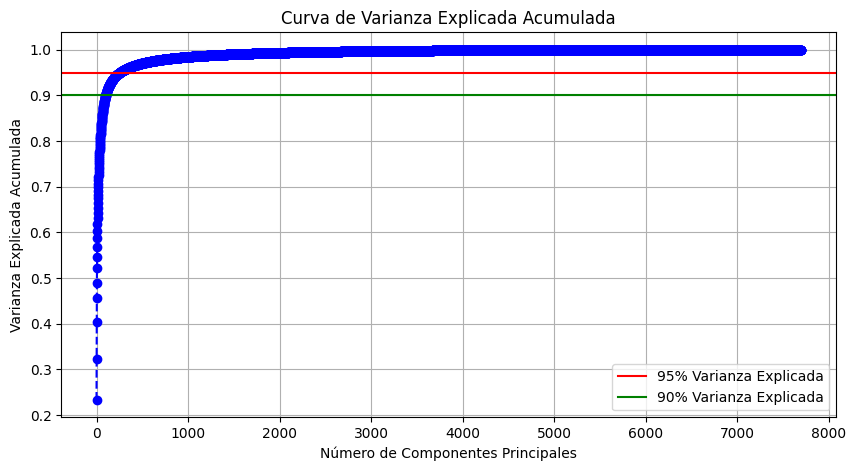

Para retener el 95% de la varianza necesitas: 257 componentes.


In [43]:
pca_multi = PCA().fit(X_multimodal)

variance_cumsum = np.cumsum(pca_multi.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(variance_cumsum, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Varianza Explicada')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Varianza Explicada')

plt.title('Curva de Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.legend()
plt.show()

components_95 = np.argmax(variance_cumsum >= 0.95) + 1
print(f"Para retener el 95% de la varianza necesitas: {components_95} componentes.")

In [44]:
print(X_multimodal.shape)

(7699, 28906)


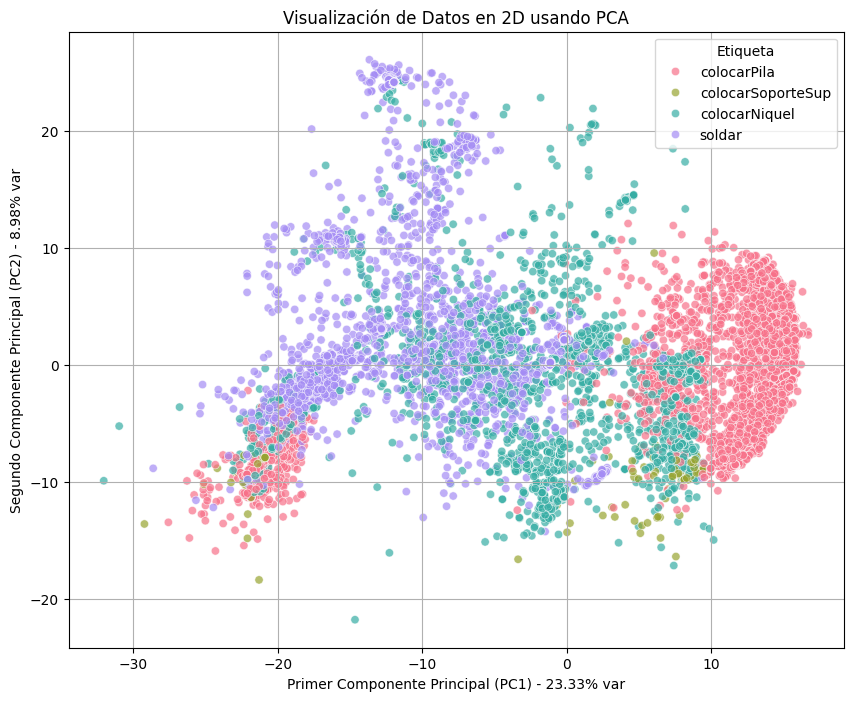

In [51]:
pca_2d = PCA(n_components=2)
x_train_pca_2d = pca_2d.fit_transform(X_multimodal)

df_pca = pd.DataFrame(x_train_pca_2d, columns=['PC1', 'PC2'])
df_pca['Etiqueta'] = y_multimodal

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Etiqueta', 
    palette='husl',  
    data=df_pca, 
    alpha=0.7
)

# porcentajes de varianza que representan esos dos ejes
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

plt.title('Visualización de Datos en 2D usando PCA')
plt.xlabel(f'Primer Componente Principal (PC1) - {var_pc1:.2f}% var')
plt.ylabel(f'Segundo Componente Principal (PC2) - {var_pc2:.2f}% var')
plt.grid(True)
plt.show()

In [54]:
pca95 = PCA(n_components=components_95)
x_pca_multimodal = pca95.fit_transform(X_multimodal)

In [ ]:
pesos = pca95.components_

pesos_imagenes = pesos[:, :28900]  # Las primeras 28,900 columnas son píxeles
pesos_coords = pesos[:, 28900:]    # Las últimas 6 columnas son los mandos

nombres_coords = ['left_x', 'left_y', 'left_z', 'right_x', 'right_y', 'right_z']

for i in range(10):
    print(f"\n--- COMPONENTE PRINCIPAL {i+1} ---")
    
    # Calcular la importancia absoluta acumulada (magnitud de los pesos)
    importancia_img = np.sum(np.abs(pesos_imagenes[i]))
    importancia_vr = np.sum(np.abs(pesos_coords[i]))
    total = importancia_img + importancia_vr
    
    print(f"Peso relativo de la IMAGEN: {(importancia_img/total)*100:.2f}%")
    print(f"Peso relativo de los MANDOS VR: {(importancia_vr/total)*100:.2f}%")
    
    print("\nImpacto detallado de cada coordenada en este componente:")
    for nombre, peso_val in zip(nombres_coords, pesos_coords[i]):
        # Un valor lejano a 0 (ya sea positivo o negativo) significa mucha influencia
        print(f"  • {nombre}: {peso_val:.4f}")


--- COMPONENTE PRINCIPAL 1 ---
Peso relativo de la IMAGEN: 99.95%
Peso relativo de los MANDOS VR: 0.05%

Impacto detallado de cada coordenada en este componente:
  • left_x: 0.0032
  • left_y: 0.0267
  • left_z: -0.0044
  • right_x: 0.0028
  • right_y: -0.0095
  • right_z: 0.0049

--- COMPONENTE PRINCIPAL 2 ---
Peso relativo de la IMAGEN: 99.90%
Peso relativo de los MANDOS VR: 0.10%

Impacto detallado de cada coordenada en este componente:
  • left_x: -0.0194
  • left_y: 0.0249
  • left_z: 0.0156
  • right_x: -0.0034
  • right_y: 0.0219
  • right_z: 0.0174

--- COMPONENTE PRINCIPAL 3 ---
Peso relativo de la IMAGEN: 99.93%
Peso relativo de los MANDOS VR: 0.07%

Impacto detallado de cada coordenada en este componente:
  • left_x: 0.0039
  • left_y: 0.0264
  • left_z: -0.0150
  • right_x: 0.0190
  • right_y: 0.0136
  • right_z: -0.0025

--- COMPONENTE PRINCIPAL 4 ---
Peso relativo de la IMAGEN: 99.90%
Peso relativo de los MANDOS VR: 0.10%

Impacto detallado de cada coordenada en este com

In [58]:
x_multi_train, x_multi_test, y_multi_train, y_multi_test = train_test_split(x_pca_multimodal, y_multimodal, test_size=0.2, random_state=42)

In [ ]:
param_grid = {'C': [0.1, 1, 10, 100], 
			'gamma': [0.01, 0.001, 0.0001], 
			'kernel': ['rbf']} 

grid_multi = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3, n_jobs=-1) 
 
grid_multi.fit(x_multi_train, y_multi_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
joblib.dump(grid_multi, "multiclassModels\modelo_multi_svm.pkl")

['multiclassModels\\modelo_multi_svm.pkl']

In [ ]:
y_multi_pred_svm = grid_multi.predict(x_multi_test)

f1_svm = f1_score(y_multi_test, y_multi_pred_svm, average="weighted")
print(f"F1 Score SVM: {f1_svm}")
print("-------------------------------------")

print("Classification Report SVM:")
print(classification_report(y_multi_test, y_multi_pred_svm, target_names=class_names))

F1 Score SVM: 0.9831134785068704
-------------------------------------
Classification Report SVM:
                   precision    recall  f1-score   support

    colocarNiquel       0.97      0.97      0.97       422
      colocarPila       1.00      1.00      1.00       617
colocarSoporteSup       0.93      0.93      0.93        55
           soldar       0.98      0.98      0.98       446

         accuracy                           0.98      1540
        macro avg       0.97      0.97      0.97      1540
     weighted avg       0.98      0.98      0.98      1540



In [72]:
show_multiclass_confusion_matrix(y_multi_test, y_multi_pred_svm, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1107  | 11    | 12    | 410   |OK
colocarPila          | 920   | 3     | 3     | 614   |OK
colocarSoporteSup    | 1481  | 4     | 4     | 51    |OK
soldar               | 1086  | 8     | 7     | 439   |OK
---------------------------------------------------------------------------


### CNN + SVM


https://arxiv.org/abs/1712.03541

In [18]:
from tensorflow.keras.regularizers import l2

def cnn_svm():
    inputs = tf.keras.Input((256, 256, 3))

    c1 = layers.Conv2D(32, (5, 5), activation = "relu", strides = (1,1))(inputs)
    p1 = layers.MaxPooling2D((2, 2), strides=(2,2))(c1)

    c2 = layers.Conv2D(64, (5, 5), activation = "relu", strides = (1,1))(p1)
    p2 = layers.MaxPooling2D((2, 2), strides=(2,2))(c2)

    f = layers.Flatten() (p2)

    fc = layers.Dense(512) (f)
    d = layers.Dropout(0.5) (fc)
    outputs = layers.Dense(4, kernel_regularizer=l2(0.01), activation='linear', name='outputs') (d)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

In [19]:
cnn_svm_model = cnn_svm()

In [74]:
# Converts a class vector (integers) to binary class matrix.
train_labels_onehot = tf.keras.utils.to_categorical(train_labels, num_classes=4)
val_labels_onehot = tf.keras.utils.to_categorical(val_labels, num_classes=4)
test_labels_onehot = tf.keras.utils.to_categorical(test_labels, num_classes=4)

# pasar de 0-1 a -1 y 1 para el SVM
train_labels_svm = (train_labels_onehot * 2.0) - 1.0
val_labels_svm = (val_labels_onehot * 2.0) - 1.0
test_labels_svm = (test_labels_onehot * 2.0) - 1.0

In [75]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels_svm, val_paths, val_labels_svm, test_paths, test_labels_svm, batch_size=16, norm_method="0_1", augment_minority=False)

In [ ]:
epochs = 20

start_time = time.time()

test_acc_cnn_svm, train_acc_cnn_svm, train_loss_cnn_svm, test_loss_cnn_svm, history_cnn_svm = training_pipeline(cnn_svm_model, train_ds, val_ds, test_ds, epochs=epochs, lr = 0.0001, compilation = 'svm', dict_weights=dict_weights)
print(f"Test accuracy: {test_acc_cnn_svm}\nTrain accuracy: {train_acc_cnn_svm}")
print(f"Test loss: {test_loss_cnn_svm}\nTrain loss: {train_loss_cnn_svm}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/20
308/308 [==============================] - 14s 42ms/step - loss: 0.0851 - accuracy: 0.9929 - val_loss: 0.1012 - val_accuracy: 0.9748 - lr: 1.0000e-04
Epoch 2/20
308/308 [==============================] - 12s 40ms/step - loss: 0.0692 - accuracy: 0.9943 - val_loss: 0.1105 - val_accuracy: 0.9773 - lr: 1.0000e-04
Epoch 3/20
308/308 [==============================] - 12s 40ms/step - loss: 0.0924 - accuracy: 0.9890 - val_loss: 0.0897 - val_accuracy: 0.9781 - lr: 1.0000e-04
Epoch 4/20
308/308 [==============================] - 12s 39ms/step - loss: 0.0781 - accuracy: 0.9903 - val_loss: 0.1034 - val_accuracy: 0.9748 - lr: 1.0000e-04
Epoch 5/20
308/308 [==============================] - 12s 39ms/step - loss: 0.0808 - accuracy: 0.9862 - val_loss: 0.1035 - val_accuracy: 0.9740 - lr: 1.0000e-04
Epoch 6/20
308/308 [==============================] - 12s 40ms/step - loss: 0.0556 - accuracy: 0.9917 - val_loss: 0.0860 - val_accuracy: 0.9789 - lr: 1.0000e-04
Epoch 7/20
308/308 [==============

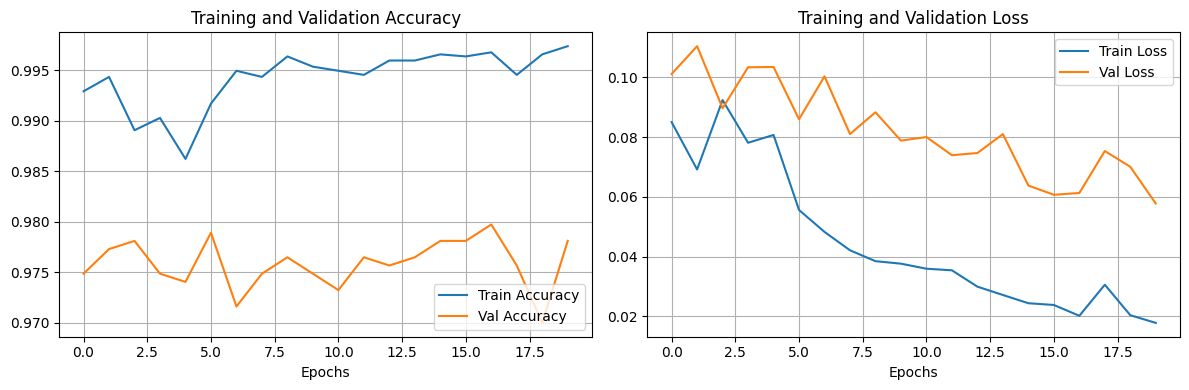

In [32]:
plot_from_history(history_cnn_svm)

In [73]:
cnn_svm_model = load_model("multiclassModels\cnn_svm_model.h5")

In [76]:
y_pred_cnn_svm = cnn_svm_model.predict(test_ds)
y_pred_classes_cnn_svm = np.argmax(y_pred_cnn_svm, axis=1)
y_true_classes = np.argmax(test_labels_svm, axis=1)
class_names = encoder.classes_

f1_cnn_svm = f1_score(y_true_classes, y_pred_classes_cnn_svm, average="weighted")
print(f"F1 Score CNN+SVM: {f1_cnn_svm}")
print("-------------------------------------")

print("Classification Report CNN+SVM:")
print(classification_report(y_true_classes, y_pred_classes_cnn_svm, target_names=class_names))

97/97 [==============================] - 4s 22ms/step
F1 Score CNN+SVM: 0.979231021648422
-------------------------------------
Classification Report CNN+SVM:
                   precision    recall  f1-score   support

    colocarNiquel       0.96      0.96      0.96       401
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.90      0.91      0.91        47
           soldar       0.98      0.97      0.98       455

         accuracy                           0.98      1540
        macro avg       0.96      0.96      0.96      1540
     weighted avg       0.98      0.98      0.98      1540



In [77]:
show_multiclass_confusion_matrix(y_true_classes, y_pred_classes_cnn_svm, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1124  | 15    | 15    | 386   |OK
colocarPila          | 900   | 3     | 1     | 636   |OK
colocarSoporteSup    | 1488  | 5     | 4     | 43    |OK
soldar               | 1076  | 9     | 12    | 443   |OK
---------------------------------------------------------------------------


Falsos FP de colocarSoporteSup: 5
=========== Falsos FP de colocarSoporteSup ===========


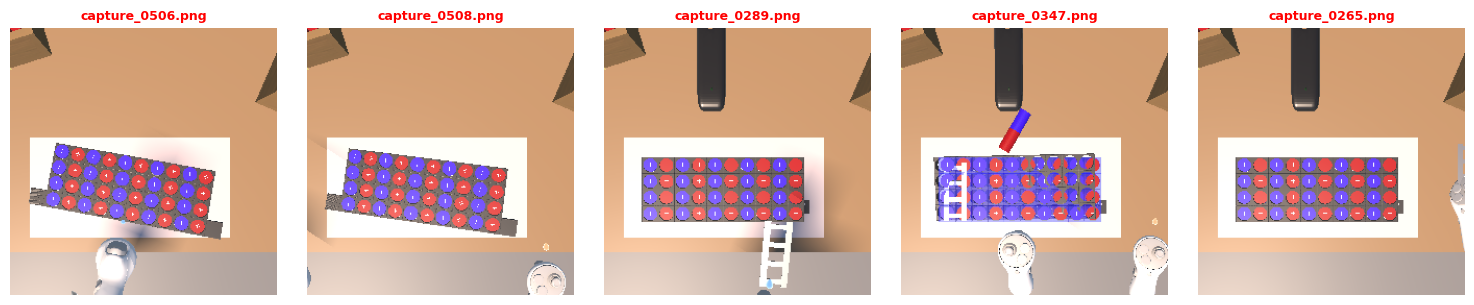

In [35]:
show_false_labels_multiclass(y_true_classes, test_paths, class_names, y_pred_classes_cnn_svm, 2, type='FP')

Falsos FN de colocarSoporteSup: 4
=========== Falsos FN de colocarSoporteSup ===========


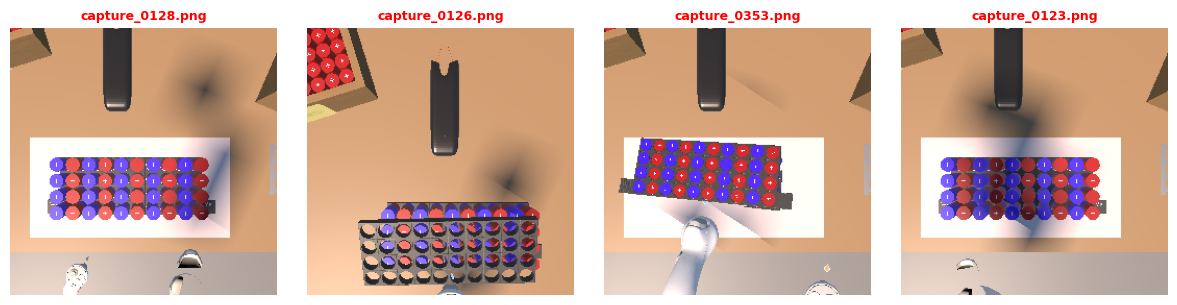

In [19]:
show_false_labels_multiclass(y_true_classes, test_paths, class_names, y_pred_classes_cnn_svm, 2, type='FN')

In [36]:
cnn_svm_model.save("multiclassModels\cnn_svm_model.h5")
save_history(history_cnn_svm, "multiclassHistories/history_cnn_svm.pkl")

## Add new synthetic data to balance classes

Cogemos las 2000 primeras imagenes de las generadas desde blender para equilibrar la clase colocarSoporteSup.  
Las imágenes generadas desde blender representan baterías con todas las pilas y el soporte superior colocadas. (las pilas pueden estar correctamente o incorrectamente colocadas)


In [17]:
new_path = '../Capturas/Capturas_256x256/Synthetic'

In [18]:
new_database = os.listdir(new_path)
new_data_img_labels = new_database[0]
new_imgs = new_database[1:]
print(new_database)
print(new_imgs)

['dataBin.csv', 'render_0000.png', 'render_0001.png', 'render_0002.png', 'render_0003.png', 'render_0004.png', 'render_0005.png', 'render_0006.png', 'render_0007.png', 'render_0008.png', 'render_0009.png', 'render_0010.png', 'render_0011.png', 'render_0012.png', 'render_0013.png', 'render_0014.png', 'render_0015.png', 'render_0016.png', 'render_0017.png', 'render_0018.png', 'render_0019.png', 'render_0020.png', 'render_0021.png', 'render_0022.png', 'render_0023.png', 'render_0024.png', 'render_0025.png', 'render_0026.png', 'render_0027.png', 'render_0028.png', 'render_0029.png', 'render_0030.png', 'render_0031.png', 'render_0032.png', 'render_0033.png', 'render_0034.png', 'render_0035.png', 'render_0036.png', 'render_0037.png', 'render_0038.png', 'render_0039.png', 'render_0040.png', 'render_0041.png', 'render_0042.png', 'render_0043.png', 'render_0044.png', 'render_0045.png', 'render_0046.png', 'render_0047.png', 'render_0048.png', 'render_0049.png', 'render_0050.png', 'render_0051.pn

In [19]:
new_csv_path = os.path.join(new_path, new_data_img_labels)

new_df = pd.read_csv(new_csv_path, header =0)

# Añadir ruta completa a cada imagen
new_df["full_path"] = new_df["filename"].apply(lambda x: os.path.join(new_path, x))

print(new_df[["filename", "label"]].tail())


             filename              label
1996  render_1996.png  colocarSoporteSup
1997  render_1997.png  colocarSoporteSup
1998  render_1998.png  colocarSoporteSup
1999  render_1999.png  colocarSoporteSup
2000  render_2000.png  colocarSoporteSup


In [46]:
full_df = pd.concat([df, new_df], ignore_index=True)

full_df["session"] = full_df["session"].fillna("Synthetic")

print(full_df[["session", "filename", "label", "full_path"]].sample(10))

print(f"\nTotal de imágenes en df: {len(df)}")
print(f"Total de imágenes en new_df: {len(new_df)}")
print(f"Total tras la combinación: {len(full_df)}")

          session                      filename              label  \
6197  Session_016  Session_016/capture_0375.png      colocarNiquel   
6598  Session_016  Session_016/capture_0776.png      colocarNiquel   
1642  Session_006  Session_006/capture_0140.png      colocarNiquel   
9535    Synthetic               render_1836.png  colocarSoporteSup   
6961  Session_017  Session_017/capture_0057.png        colocarPila   
8618    Synthetic               render_0919.png  colocarSoporteSup   
5110  Session_014  Session_014/capture_0042.png        colocarPila   
3790  Session_010  Session_010/capture_0529.png             soldar   
6981  Session_017  Session_017/capture_0077.png        colocarPila   
8931    Synthetic               render_1232.png  colocarSoporteSup   

                                              full_path  
6197  ../capturas/capturas_256x256/capturasVR\Sessio...  
6598  ../capturas/capturas_256x256/capturasVR\Sessio...  
1642  ../capturas/capturas_256x256/capturasVR\Sessio...

c:\Users\Usuario\Desktop\TFM\TFM_InteligentTutor\modelos\functions\plottingFunctions.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


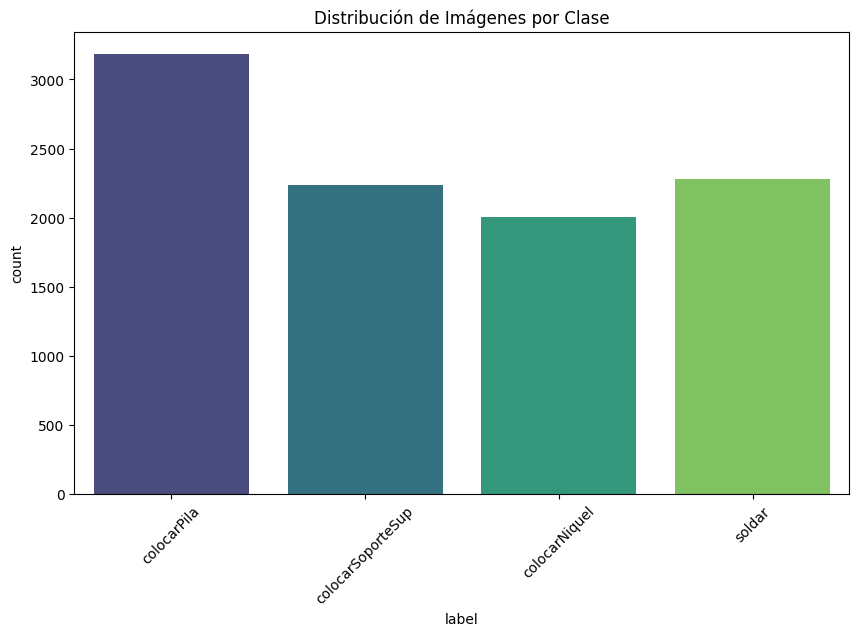

In [18]:
show_class_distribution(full_df)

In [21]:
(full_train_paths, full_train_labels), (full_val_paths, full_val_labels), (full_test_paths, full_test_labels), encoder = get_paths_and_labels(full_df, test_size=0.2)

print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(full_train_paths) + len(full_val_paths) + len(full_test_paths)}")
print(f"Entrenamiento: {len(full_train_paths)}")
print(f"Validación:    {len(full_val_paths)}")
print(f"Test:          {len(full_test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(full_df['label'].value_counts())
print(full_df['label'].value_counts(normalize=True) * 100)

['colocarNiquel' 'colocarPila' 'colocarSoporteSup' 'soldar']
ID 0 -> Clase: colocarNiquel
ID 1 -> Clase: colocarPila
ID 2 -> Clase: colocarSoporteSup
ID 3 -> Clase: soldar
Total: 9700
Entrenamiento: 6208
Validación:    1552
Test:          1940

Distribución de clases en el dataset completo:
label
colocarPila          3184
soldar               2276
colocarSoporteSup    2238
colocarNiquel        2002
Name: count, dtype: int64
label
colocarPila          32.824742
soldar               23.463918
colocarSoporteSup    23.072165
colocarNiquel        20.639175
Name: proportion, dtype: float64


In [47]:
full_train_ds, full_val_ds, full_test_ds = get_dataset(full_train_paths, full_train_labels, full_val_paths, full_val_labels, full_test_paths, full_test_labels, 32, "neg1_1", False)

### Mobilenet V1

In [34]:
from keras.applications import MobileNet

In [48]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_mobilenet_full = Sequential([
    base_mobilenet,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 20

test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_mobilenet_full = training_pipeline(model_mobilenet_full, full_train_ds, full_val_ds, full_test_ds, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/20
194/194 [==============================] - 28s 135ms/step - loss: 0.3537 - accuracy: 0.8645 - val_loss: 2.7501 - val_accuracy: 0.2307 - lr: 1.0000e-04
Epoch 2/20
194/194 [==============================] - 26s 134ms/step - loss: 0.0913 - accuracy: 0.9712 - val_loss: 4.5325 - val_accuracy: 0.2307 - lr: 1.0000e-04
Epoch 3/20
194/194 [==============================] - 26s 136ms/step - loss: 0.0590 - accuracy: 0.9821 - val_loss: 7.6391 - val_accuracy: 0.2307 - lr: 1.0000e-04
Epoch 4/20
194/194 [==============================] - ETA: 0s - loss: 0.0389 - accuracy: 0.9878
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
194/194 [==============================] - 26s 136ms/step - loss: 0.0389 - accuracy: 0.9878 - val_loss: 3.3664 - val_accuracy: 0.2912 - lr: 1.0000e-04
Epoch 5/20
194/194 [==============================] - 26s 135ms/step - loss: 0.0246 - accuracy: 0.9932 - val_loss: 0.0568 - val_accuracy: 0.9807 - lr: 5.0000e-05
Epoch 6/20
194/194 [=========

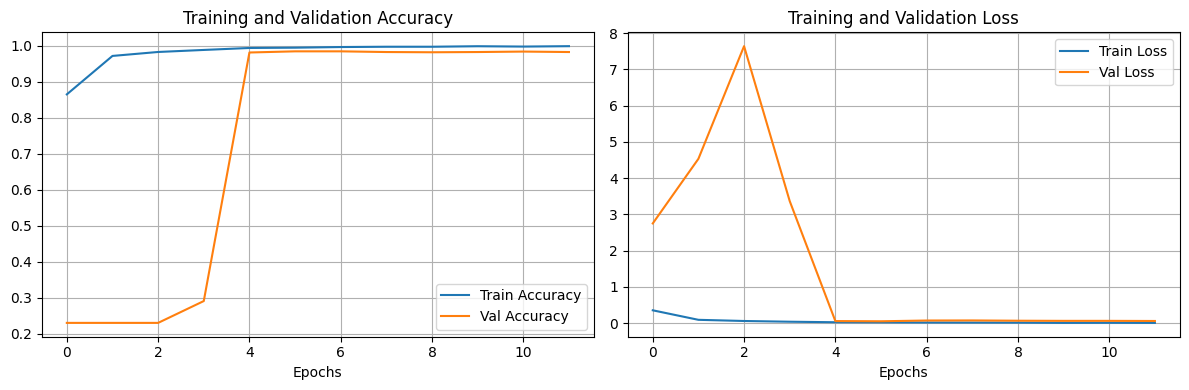

In [49]:
plot_from_history(history_mobilenet_full)

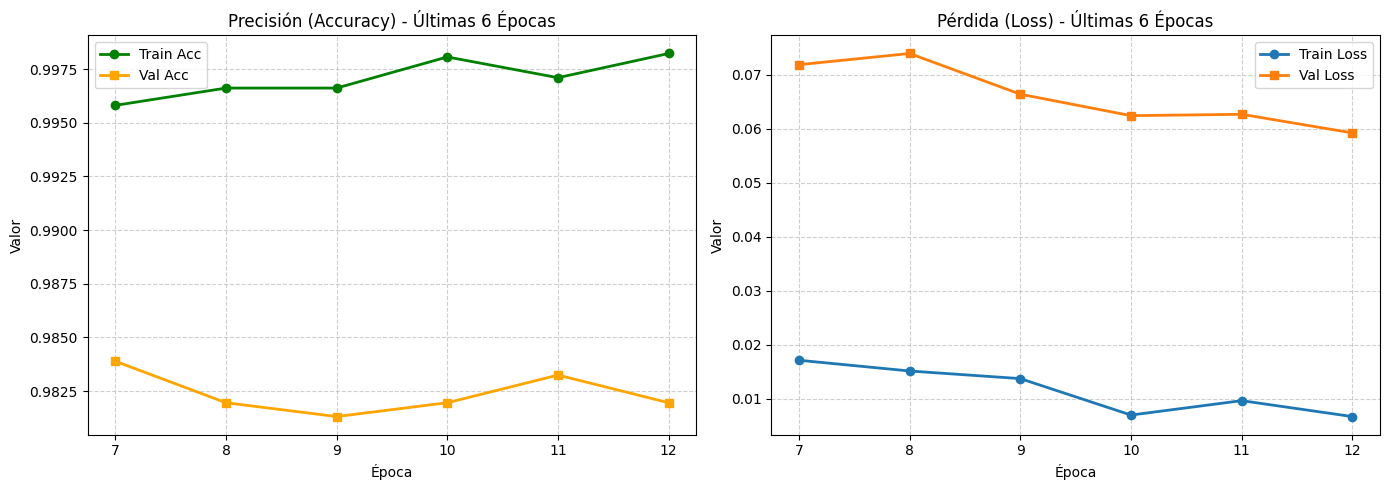

In [50]:
show_last_epochs(history_mobilenet_full, idx = 6)

In [51]:
model_mobilenet_full.save("multiclassModels\model_mobilenet_full.h5")
save_history(history_mobilenet_full, "multiclassHistories\history_mobilenet_full.pkl")

In [56]:
model_mobilenet_full = load_model("multiclassModels\model_mobilenet_full.h5")

In [57]:
y_pred_mobilenet = model_mobilenet_full.predict(full_test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(full_test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(full_test_labels, y_pred_classes_mobilenet, target_names=class_names))

61/61 [==============================] - 3s 37ms/step
F1 Score MobileNet: 0.9856052182205872
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.96      0.98      0.97       400
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.99      0.98      0.99       448
           soldar       0.99      0.98      0.98       455

         accuracy                           0.99      1940
        macro avg       0.98      0.98      0.98      1940
     weighted avg       0.99      0.99      0.99      1940



In [58]:
show_multiclass_confusion_matrix(full_test_labels, y_pred_classes_mobilenet, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1523  | 17    | 8     | 392   |OK
colocarPila          | 1300  | 3     | 3     | 634   |OK
colocarSoporteSup    | 1488  | 4     | 7     | 441   |OK
soldar               | 1481  | 4     | 10    | 445   |OK
---------------------------------------------------------------------------


Hay 7 casos de tipo [FN] para la clase 'colocarSoporteSup'


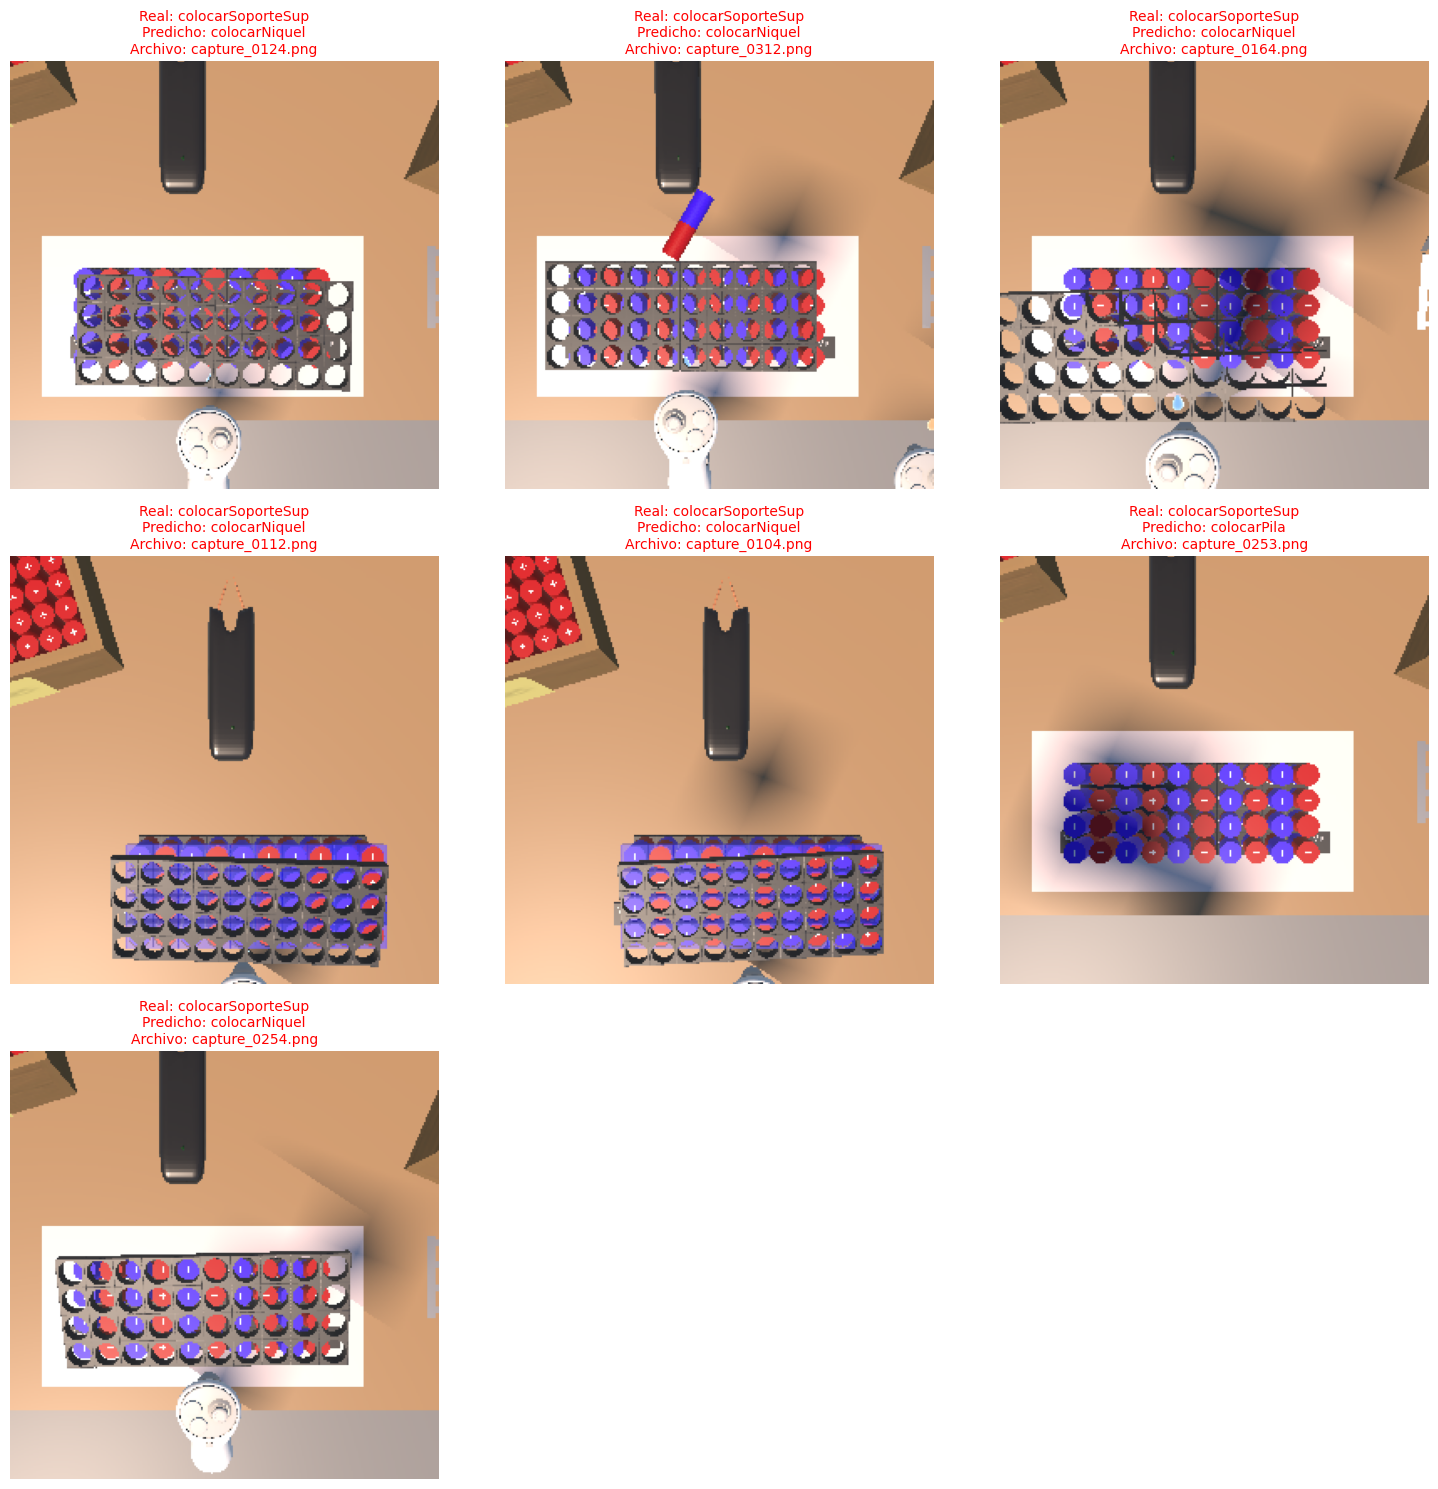

In [54]:
show_imgs(full_test_paths, full_test_labels, y_pred_classes_mobilenet, class_names, clase_nombre="colocarSoporteSup", tipo_caso="FN", max_imagenes=7)

Las imágenes sintéticas representan el momento en el que el soporte superior ya está colocado en la batería, no mientras se está colocando.

Hay 4 casos de tipo [FP] para la clase 'colocarSoporteSup'


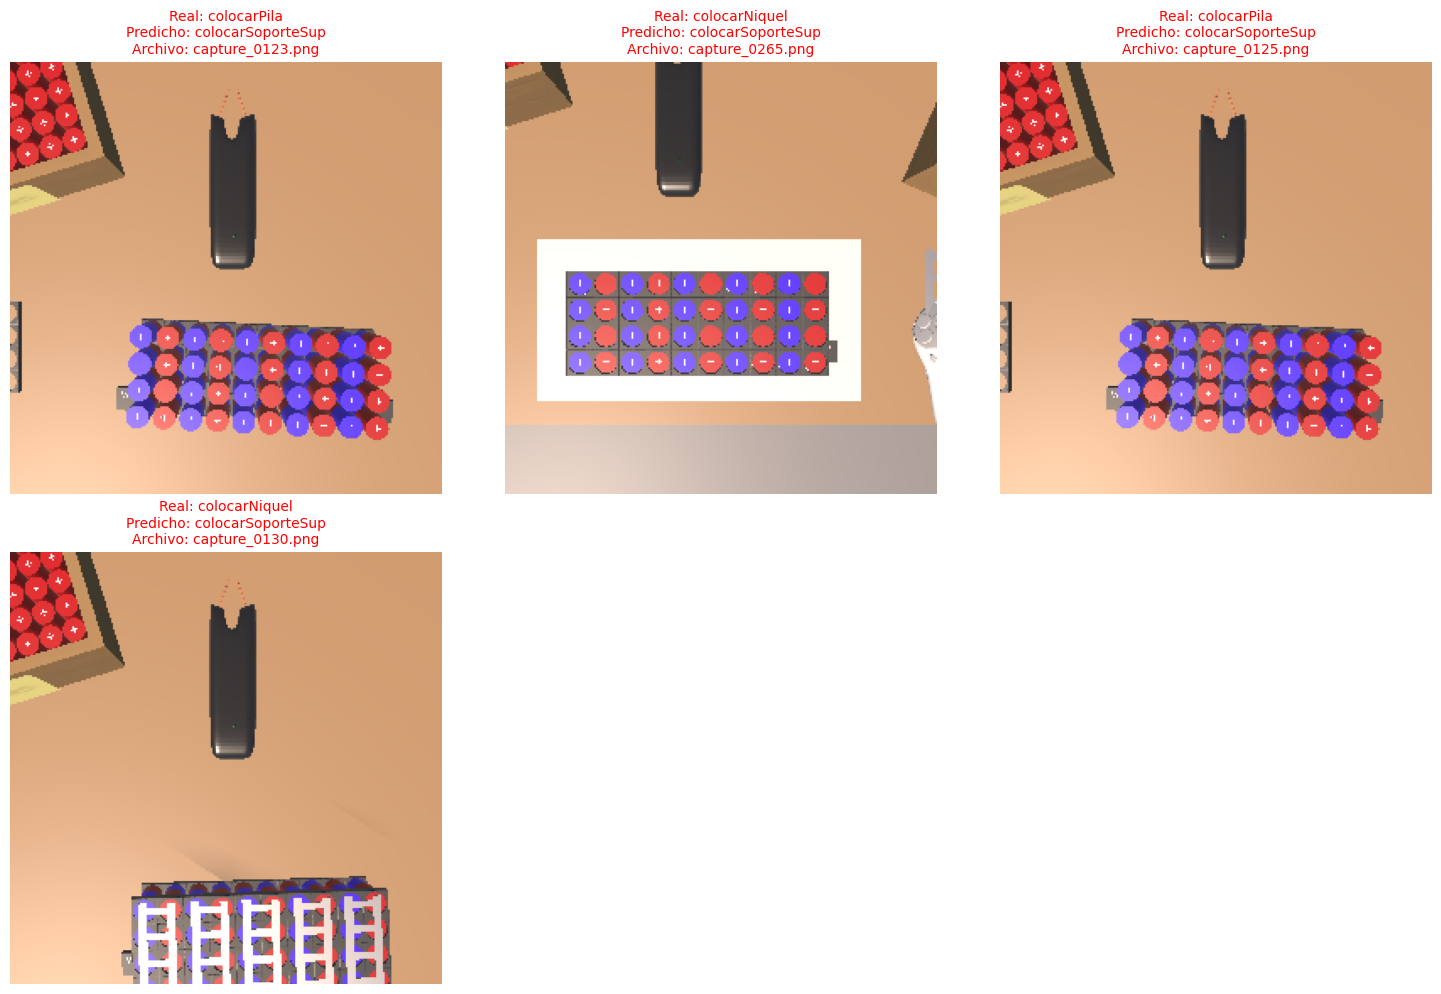

In [55]:
show_imgs(full_test_paths, full_test_labels, y_pred_classes_mobilenet, class_names, clase_nombre="colocarSoporteSup", tipo_caso="FP")

### moblenet V2

In [22]:
from keras.applications import MobileNetV2
from keras.applications import mobilenet_v2

In [59]:
batch_size = 16

# --- DATASET DE ENTRENAMIENTO ---
full_train_ds = tf.data.Dataset.from_tensor_slices((full_train_paths, full_train_labels))
full_train_ds = (full_train_ds
            .shuffle(len(full_train_paths))
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
            .map(lambda x, y: (mobilenet_v2.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --- DATASET DE VALIDACIÓN ---
full_val_ds = tf.data.Dataset.from_tensor_slices((full_val_paths, full_val_labels))
full_val_ds = (full_val_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) 
            .map(lambda x, y: (mobilenet_v2.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --- DATASET DE TEST ---
full_test_ds = tf.data.Dataset.from_tensor_slices((full_test_paths, full_test_labels))
full_test_ds = (full_test_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) 
            .map(lambda x, y: (mobilenet_v2.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))


In [60]:
start_time = time.time()

base_mobilenetV2 = MobileNetV2(
    include_top = False,
    weights = 'imagenet',
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_mobilenetV2_full = Sequential([
    base_mobilenetV2,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 50

test_acc_mobilenetV2, train_acc_mobilenetV2, train_loss_mobilenetV2, test_loss_mobilenetV2, history_mobilenetV2_full = training_pipeline(model_mobilenetV2_full, full_train_ds, full_val_ds, full_test_ds,patience=5, epochs=epochs, lr = 0.001)
print(f"Test accuracy: {test_acc_mobilenetV2}\nTrain accuracy: {train_acc_mobilenetV2}")
print(f"Test loss: {test_loss_mobilenetV2}\nTrain loss: {train_loss_mobilenetV2}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/50
388/388 [==============================] - 38s 88ms/step - loss: 0.1678 - accuracy: 0.9476 - val_loss: 5.0207 - val_accuracy: 0.5316 - lr: 0.0010
Epoch 2/50
388/388 [==============================] - 33s 86ms/step - loss: 0.1258 - accuracy: 0.9601 - val_loss: 4.4701 - val_accuracy: 0.5651 - lr: 0.0010
Epoch 3/50
388/388 [==============================] - 34s 87ms/step - loss: 0.0923 - accuracy: 0.9762 - val_loss: 7.4930 - val_accuracy: 0.5567 - lr: 0.0010
Epoch 4/50
388/388 [==============================] - 34s 87ms/step - loss: 0.0749 - accuracy: 0.9787 - val_loss: 18.1357 - val_accuracy: 0.3872 - lr: 0.0010
Epoch 5/50
388/388 [==============================] - 34s 87ms/step - loss: 0.0572 - accuracy: 0.9837 - val_loss: 3.9924 - val_accuracy: 0.5470 - lr: 0.0010
Epoch 6/50
388/388 [==============================] - 34s 87ms/step - loss: 0.0612 - accuracy: 0.9824 - val_loss: 5.8417 - val_accuracy: 0.4317 - lr: 0.0010
Epoch 7/50
388/388 [==============================] - 34s

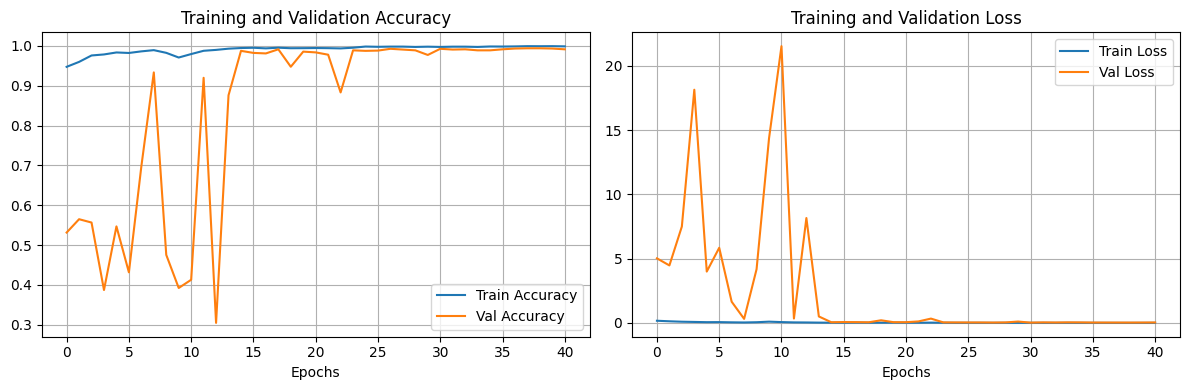

In [61]:
plot_from_history(history_mobilenetV2_full)

In [62]:
history_mobilenetV2_full = load_history("multiclassHistories\history_mobilenetV2_full.pkl")

Historial cargado desde multiclassHistories\history_mobilenetV2_full.pkl.


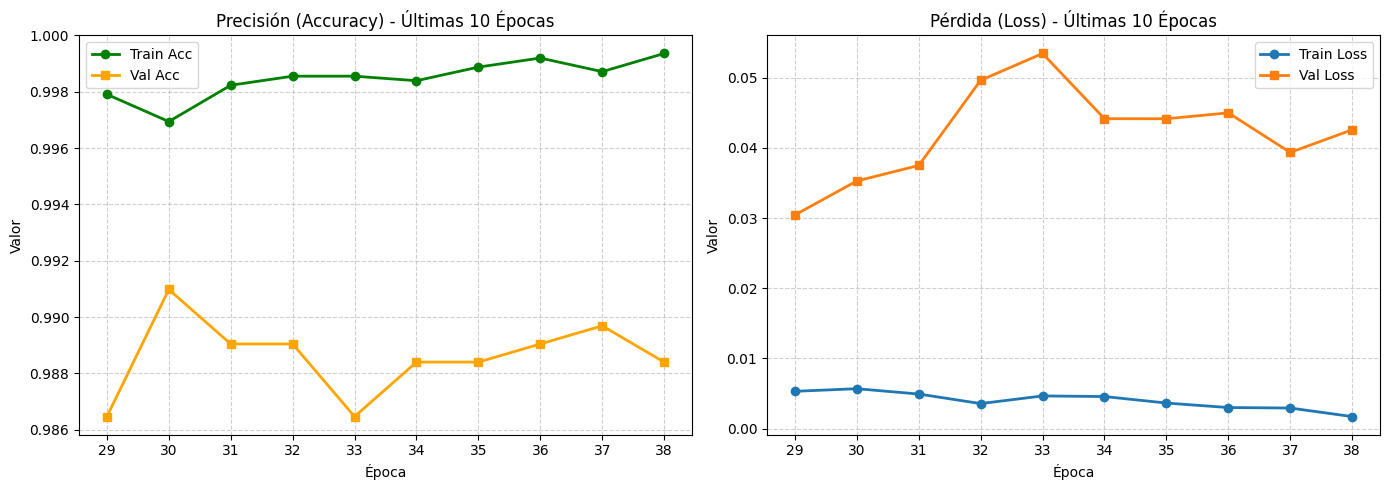

In [14]:
show_last_epochs(history_mobilenetV2_full, 10)

In [ ]:
model_mobilenetV2_full.save("multiclassModels\model_mobilenetV2_full.h5")
save_history(history_mobilenetV2_full, "multiclassHistories\history_mobilenetV2_full.pkl")

In [15]:
model_mobilenetV2_full = load_model("multiclassModels\model_mobilenetV2_full.h5")

In [63]:
y_pred_mobilenetV2 = model_mobilenetV2_full.predict(full_test_ds)
y_pred_classes_mobilenetV2 = y_pred_mobilenetV2.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenetV2 = f1_score(full_test_labels, y_pred_classes_mobilenetV2, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenetV2}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(full_test_labels, y_pred_classes_mobilenetV2, target_names=class_names))

122/122 [==============================] - 4s 24ms/step
F1 Score MobileNet: 0.9932973218854756
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.98      0.98      0.98       400
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       1.00      1.00      1.00       448
           soldar       0.99      0.99      0.99       455

         accuracy                           0.99      1940
        macro avg       0.99      0.99      0.99      1940
     weighted avg       0.99      0.99      0.99      1940



In [64]:
show_multiclass_confusion_matrix(full_test_labels, y_pred_classes_mobilenetV2, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1534  | 6     | 7     | 393   |OK
colocarPila          | 1303  | 0     | 0     | 637   |Perfecto
colocarSoporteSup    | 1490  | 2     | 2     | 446   |OK
soldar               | 1480  | 5     | 4     | 451   |OK
---------------------------------------------------------------------------


Hay 2 casos de tipo [FP] para la clase 'colocarSoporteSup'


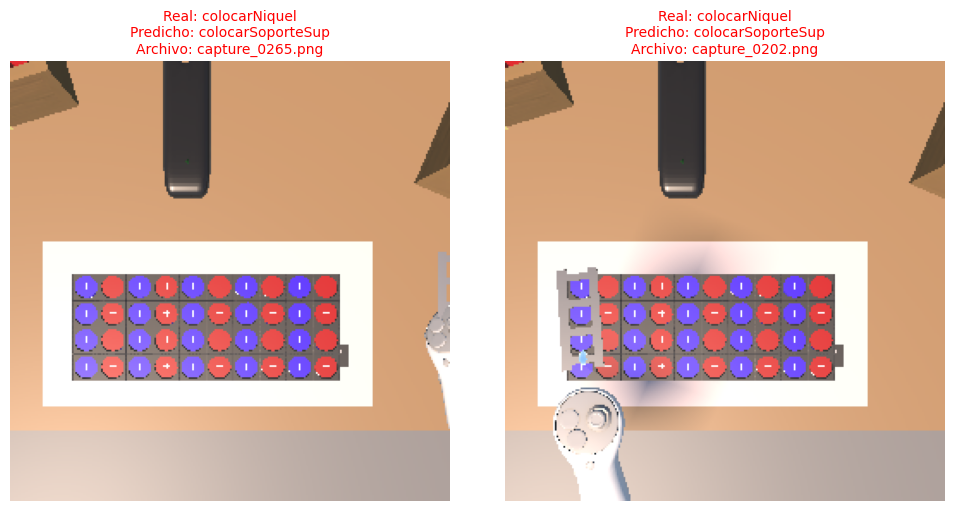

In [28]:
show_imgs(full_test_paths, full_test_labels, y_pred_classes_mobilenetV2, class_names, clase_nombre="colocarSoporteSup", tipo_caso="FP", max_imagenes=2)

Hay 1 casos de tipo [FN] para la clase 'colocarSoporteSup'


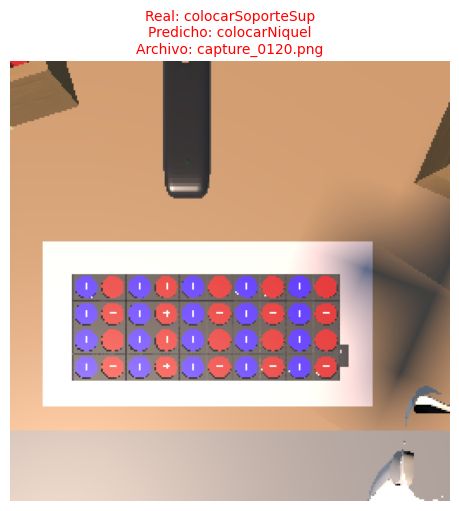

In [25]:
show_imgs(full_test_paths, full_test_labels, y_pred_classes_mobilenetV2, class_names, clase_nombre="colocarSoporteSup", tipo_caso="FN", max_imagenes=1)

Hay 6 casos de tipo [FP] para la clase 'colocarNiquel'


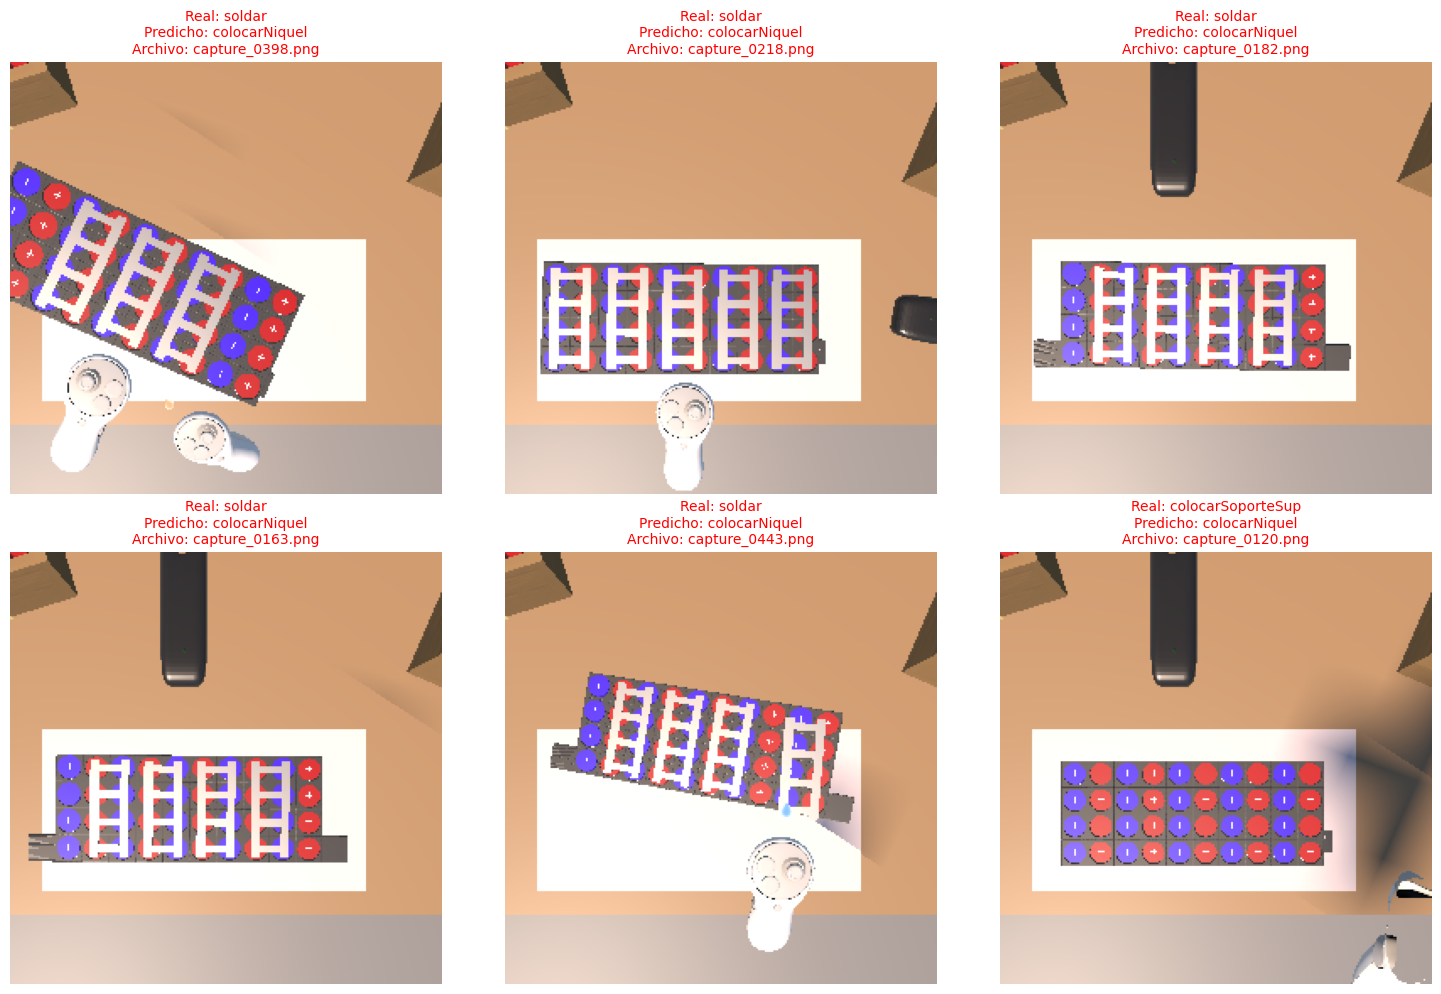

In [26]:
show_imgs(full_test_paths, full_test_labels, y_pred_classes_mobilenetV2, class_names, clase_nombre="colocarNiquel", tipo_caso="FP", max_imagenes=6)